<!-- ## Summarize the results -->

<!-- ### ELBO -->

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import torch
import re
import pandas as pd
import seaborn as sns
from model_rnn import AEVB
from network_visualization import plot_all_circular_matrices, animate_bubble_matrices_vertical, plot_circular_matrices_4xK_colorbars_on_right, reshape_rows_with_corners_as_nans

from sklearn.metrics.pairwise import cosine_similarity
import torch.distributions as td

In [4]:
# Define the path pattern to match all output .pth files in the directory
# file_pattern = 'results/realdata/output_*.pth'
# file_pattern = "results/hp02_reconerror/output_*.pth"
# file_pattern = "results/newdata/output_*.pth"
# file_pattern = "results/realdata_reconerror/output_*.pth"
# file_pattern = "results/gbz250/output_*.pth"
# file_pattern = "results/newdata/output_*.pth"
file_pattern = "results/4week_rnn/recon_error/output_*.pth"
# file_pattern = "results/hp1dup/output_*.pth"
# file_pattern = "results/hp02/output_*.pth"
# Use glob to find all files that match the pattern
file_paths = glob.glob(file_pattern)

# Create a list to store ELBO data with filename, K, set, and seed information
elbo_data = []
last_elbo_data = []

# Regex pattern to extract the base filename, K, set, and seed numbers from the filename
pattern = r'output_(.*?)_K(\d+)_seed(\d+)\_lambda([\d.]+)\.pth'

# Iterate over the file paths and extract ELBO data
for file_path in file_paths:
    # Extract the file name
    file_name = file_path.split('/')[-1]
    
    # Extract base filename, K, set, and seed using regex
    match = re.search(pattern, file_name)
    if match:
        base_filename = match.group(1)#.split("_")[0]
        K = int(match.group(2))
        seed = int(match.group(3))
        lambda_value = float(match.group(4))
        
        # Load the PyTorch file
        data = torch.load(file_path, weights_only=False)

        # Extract the ELBO key if it exists
        if 'ELBO' in data:
            elbo_list = data['ELBO']
            if data["predictions"] is not None:
                # Extract the predictions and reconstruction error if they exist
                recon_error = data["predictions"]["rmse"].cpu().numpy()
            else:
                recon_error = None
            elbo_data.append({'filename': base_filename, 'K': K, 'seed': seed, "lambda_value": lambda_value, 'ELBO': elbo_list})
            # Append the data to our list with associated filename, K, set, seed, and the last ELBO value
            last_elbo_data.append({'filename': base_filename, 'K': K, 'seed': seed, "lambda_value": lambda_value, 'ELBO': elbo_list[-1], "recon_error": recon_error})

# Convert the list to a DataFrame for easier analysis
df_last_elbo = pd.DataFrame(last_elbo_data)
# df_last_elbo["recon_error"] = df_last_elbo["recon_error"].astype(float)


In [5]:
best_configs = []
filenames = df_last_elbo["filename"].unique()
for filename in filenames:
    df = df_last_elbo[df_last_elbo["filename"] == filename]
    # mean_recon_error_per_lambdah = df.groupby("lambda_value")["recon_error"].mean().astype(float)
    best_lambda = 0.1 # mean_recon_error_per_lambdah.idxmin()
    df_best_lambda = df[df["lambda_value"] == best_lambda]
    idx_min_ELBO = df_best_lambda["ELBO"].idxmin()
    best_seed = df_best_lambda.loc[idx_min_ELBO, "seed"]
    min_ELBO = df_best_lambda.loc[idx_min_ELBO, "ELBO"]
    best_config = df_best_lambda.loc[idx_min_ELBO]
    best_configs.append(best_config)
    
df_best_configs = pd.DataFrame(best_configs)
print(df_best_configs)

      filename   K  seed  lambda_value       ELBO recon_error
0   p3b1_4week  10    10           0.1  51.060680    3.671458
14  p1b2_4week  10    10           0.1  46.576023   3.6781304
23  p5a2_4week  10     3           0.1  29.390184   4.1650276


In [6]:
df_min_elbo = df_best_configs

In [5]:
# df_min_elbo.to_csv("results/developmental_violin/selected.csv", index=False)

In [5]:
# df_min_elbo.to_csv("results/newdata/selected.csv", index=False)

<!-- ### Given the lowest ELBO, check the results -->

<!-- #### Data visualization -->

In [7]:
i = 2
data_path = "4weekdata/"+df_min_elbo.iloc[i]["filename"]+".npy"
# data_path = "hp_files/"+df_min_elbo.iloc[i]["filename"]+".npy"
# data_path = "concatdata/"+df_min_elbo.iloc[i]["filename"]+".npy"
# data_path = "GBZ250/"+df_min_elbo.iloc[i]["filename"]+".npy"
# data_path = "tempdata.npy"
data_path

'4weekdata/p5a2_4week.npy'

In [8]:
# data = np.load(data_path+".npy")
data = np.load(data_path)
data.shape

(2376, 64)

In [9]:
# data1 = np.load("hp_files/tc048_DIV21.npy")
# data_dup = np.concatenate([data, data1], axis=0)
# np.save("hp_dup/tc043_DIV14_tc048_DIV21.npy", data_dup)

In [10]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import signal
# import torch

# def analyze_neural_periodicity(y_data, plot=True):
#     """
#     Comprehensive analysis of periodic structure in neural spiking data
    
#     Args:
#         y_data: (T, D) array of spike counts
#         plot: Whether to generate diagnostic plots
#     """
#     T, D = y_data.shape
    
#     # 1. AUTOCORRELATION ANALYSIS
#     print("=== AUTOCORRELATION ANALYSIS ===")
#     autocorr_peaks = []
    
#     for electrode in range(min(D, 10)):  # Analyze first 10 electrodes
#         # Compute autocorrelation
#         signal_data = y_data[:, electrode]
#         autocorr = np.correlate(signal_data, signal_data, mode='full')
#         autocorr = autocorr[autocorr.size // 2:]  # Keep positive lags only
        
#         # Find peaks in autocorrelation (indicating periodicity)
#         peaks, properties = signal.find_peaks(autocorr[1:], height=np.max(autocorr)*0.1)
#         if len(peaks) > 0:
#             primary_period = peaks[0] + 1  # +1 because we started from index 1
#             autocorr_peaks.append(primary_period)
    
#     if autocorr_peaks:
#         avg_period = np.mean(autocorr_peaks)
#         print(f"Average period across electrodes: {avg_period:.1f} time steps")
    
#     # 2. FOURIER ANALYSIS
#     print("\n=== FOURIER ANALYSIS ===")
#     dominant_periods = []
    
#     for electrode in range(min(D, 10)):
#         # Compute power spectral density
#         freqs, psd = signal.periodogram(y_data[:, electrode], fs=1.0)
        
#         # Find dominant frequency (skip DC component)
#         dominant_freq_idx = np.argmax(psd[1:]) + 1
#         dominant_freq = freqs[dominant_freq_idx]
        
#         if dominant_freq > 0:
#             dominant_period = 1.0 / dominant_freq
#             dominant_periods.append(dominant_period)
    
#     if dominant_periods:
#         fft_avg_period = np.mean(dominant_periods)
#         print(f"Average period from FFT: {fft_avg_period:.1f} time steps")
    
#     # 3. PATTERN REPETITION ANALYSIS
#     print("\n=== PATTERN REPETITION ANALYSIS ===")
    
#     # Look for repeating subsequences
#     def find_repeating_patterns(data, min_length=10, max_length=50):
#         patterns = {}
#         for length in range(min_length, min_length + max_length):
#             for start in range(len(data) - 2*length):
#                 pattern = tuple(data[start:start+length])
#                 next_occurrence = data[start+length:start+2*length]
                
#                 # Check if pattern repeats
#                 if np.array_equal(pattern, next_occurrence):
#                     if pattern not in patterns:
#                         patterns[pattern] = []
#                     patterns[pattern].append(start)
        
#         return patterns
    
#     # Analyze a few electrodes for repeating patterns
#     for electrode in range(min(D, 3)):
#         patterns = find_repeating_patterns(y_data[:, electrode])
#         if patterns:
#             pattern_lengths = [len(p) for p in patterns.keys()]
#             print(f"Electrode {electrode}: Found {len(patterns)} repeating patterns, "
#                   f"lengths {min(pattern_lengths)}-{max(pattern_lengths)}")
    
#     # 4. CROSS-ELECTRODE SYNCHRONY
#     print("\n=== CROSS-ELECTRODE SYNCHRONY ===")
    
#     # Compute pairwise correlations
#     corr_matrix = np.corrcoef(y_data.T)
#     avg_correlation = np.mean(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
#     print(f"Average pairwise correlation: {avg_correlation:.3f}")
    
#     if avg_correlation > 0.3:
#         print("HIGH synchrony detected - suggests coordinated periodic activity")
#     elif avg_correlation > 0.1:
#         print("MODERATE synchrony detected - some coordination present")
#     else:
#         print("LOW synchrony - electrodes mostly independent")
    
#     # 5. RECOMMENDATIONS
#     print("\n=== MODEL RECOMMENDATIONS ===")
    
#     if autocorr_peaks and np.mean(autocorr_peaks) < T/10:
#         period_est = np.mean(autocorr_peaks)
#         print(f"✓ STRONG PERIODICITY detected (period ≈ {period_est:.0f})")
#         print("Recommendations:")
#         print("  1. Add explicit periodic components to your model")
#         print("  2. Use longer-range dependencies (period = {:.0f})".format(period_est))

    
#     # 6. PLOTTING
#     if plot:
#         fig, axes = plt.subplots(1, 2, figsize=(12, 8))
        
#         # Plot 3: Cross-correlation matrix
#         corr_matrix = np.corrcoef(y_data.T)
#         im = axes[0].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
#         axes[0].set_title('Cross-Electrode Correlations')
#         plt.colorbar(im, ax=axes[0])
        
#         # Plot 4: Mean activity over time (to visualize periods)
#         mean_activity = np.mean(y_data, axis=1)
#         axes[1].plot(mean_activity)
#         axes[1].set_title('Mean Activity Across Electrodes')
#         axes[1].set_xlabel('Time')
        
#         plt.tight_layout()
#         plt.show()
    
#     return {
#         'autocorr_periods': autocorr_peaks,
#         'fft_periods': dominant_periods,
#         'avg_correlation': avg_correlation,
#         'period_estimate': np.mean(autocorr_peaks) if autocorr_peaks else None
#     }

# # Example usage:
# # results = analyze_neural_periodicity(your_data)

In [11]:
# analyze_neural_periodicity(data, plot=True)

In [9]:
T = data.shape[0]
D = data.shape[1]

In [10]:
# output_path_prefix = "results/developmental_violin/output_"
# output_path_prefix = "results/realdata/output_"
# output_path_prefix = "results/hp1dup/output_"
# output_path_prefix = "results/hp02/output_"
# output_path_prefix = "results/newdata/output_"
output_path_prefix = "results/4week_rnn/recon_error/output_"  
# output_path_prefix = "results/gbz250/output_"

output_path = output_path_prefix+ str(df_min_elbo["filename"].iloc[i]) + "_K" + str(df_min_elbo["K"].iloc[i]) + "_seed" + str(df_min_elbo["seed"].iloc[i]) + "_lambda"+ str(df_min_elbo["lambda_value"].iloc[i]) + ".pth"
# output_path = output_path_prefix+ str(df_min_elbo["filename"].iloc[i]) + "_K" + str(10) + "_seed" + str(df_min_elbo["seed"].iloc[i]) + ".pth"
# output_path = "results/output_tempdata_K5_seed42_lambda0.05.pth"
# output_path = output_path_prefix+files.split(".")[0] + "_K" + str(8) + "_seed" + str(result["seed"][i]) + ".pth"
model_path = output_path.replace("output", "model")

In [11]:
# K=df_min_elbo["K"].iloc[i]
# K = 5
K = 10

In [12]:
from model_holdout import AEVB

In [12]:
from model_rnn import AEVB

In [13]:
output = torch.load(output_path, weights_only=False)
T, D = output["mu_approx"].shape
model = AEVB(T=T, D=D, K=K, lambda_h=0.5)
model.load_state_dict(torch.load(model_path), strict=False)

<All keys matched successfully>

In [14]:
h_learned = torch.sigmoid(output['h_logit']).detach().cpu().numpy()
z_learned = output['z'].detach().cpu().numpy()
theta_learned = torch.abs(model.theta).detach().cpu().numpy()
mu_approx = output['mu_approx'].detach().cpu().numpy()
mu0_approx = output['mu0_approx'].detach().cpu().numpy()
z0_learned = output['z0'].detach().cpu().numpy()
theta0_learned = torch.abs(model.theta0).detach().cpu().numpy()

In [15]:
h_hard = (h_learned>0.5)
count_ones = np.sum(h_hard, axis=0)

# Step 3: Sort the indices based on the count of ones in descending order
sorted_indices = np.argsort(-count_ones)

# Step 4: Reorder the arrays using the sorted indices
h_hard_sorted = h_hard[:, sorted_indices]
h_est_sorted = h_learned[:, sorted_indices]

In [16]:
h_learned_reordered = h_learned[:, sorted_indices]
h_hard_reordered = h_hard[:, sorted_indices]   
z_learned_reordered = z_learned[:, sorted_indices]

In [18]:
def plot(output, model, gt, mu, file_str,T,D,K, vmax_percentile = 95):
    plt.rcParams.update({'font.size': 18})
    vmax = np.percentile(gt, vmax_percentile)
    h_learned = torch.sigmoid(output['h_logit']).detach().cpu().numpy()
    z_learned = output['z'].detach().cpu().numpy()
    
    z0_learned = output['z0'].detach().cpu().numpy()
    h_hard = (h_learned>0.5)
    count_ones = np.sum(h_hard, axis=0)

    sorted_indices = np.argsort(-count_ones)
    h_learned_reordered = h_learned[:, sorted_indices]
    z_learned_reordered = z_learned[:, sorted_indices]
    theta_learned = torch.abs(model.theta).detach().cpu().numpy()
    theta_learned_reordered = theta_learned[sorted_indices]
    theta_scale =theta_learned_reordered.max(axis=1) ##changed from max to sum
    #theta_scale /=2
    z_learned_scaled = np.exp(z_learned_reordered) * theta_scale
    
    z_h_learned = z_learned_scaled * h_learned_reordered
    z_z0_learned = np.hstack([z0_learned, z_h_learned])
    
    div_ticks = [300, 900, 1500, 2100]  # Update as needed to match T
    div_labels = ['DIV14', 'DIV21', 'DIV28', 'DIV35']
    
    fig = plt.figure(figsize=(T/150, .5*K))
    ax = plt.axes()
    im = ax.imshow(h_learned_reordered.T, aspect='auto', interpolation="none", cmap='Greys')
    #ax.set_title("True h")
    ax.set_xlabel("Time")
    ax.set_ylabel("Feature")
    ax.set_yticks(range(K), np.arange(1, K+1))
    ax.vlines([T/2], ymin=0, ymax=K-0.5, color='lavender', linestyle=':')    # ax.set_yticks(div_ticks)
    # ax.set_yticklabels(div_labels)
    # plt.savefig("figures/true_h.png")
    cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
    # plt.savefig("figures/{}_learned_h.png".format(file_str),bbox_inches='tight')
    plt.show()
    
    fig = plt.figure(figsize=(T/150, .5*(K+1)))
    ax = plt.axes()
    im = ax.imshow(z_z0_learned.T, aspect='auto', interpolation='None', cmap="plasma", vmin=0, vmax=vmax)
    #ax.set_title("Learned Theta")
    ax.set_xlabel("Time")
    ax.set_ylabel("Feature")
    ax.set_yticks(range(K+1))
    ax.vlines([T/2], ymin=0, ymax=K-0.5, color='lavender', linestyle=':')
    # ax.set_yticks(div_ticks)
    # ax.set_yticklabels(div_labels)
    cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
    # plt.savefig("figures/{}learned_zh.png".format(file_str),bbox_inches='tight')
    plt.show()
    
    fig = plt.figure(figsize=(T/150, 5))
    ax = plt.axes()
    im = ax.imshow(gt, aspect='auto', interpolation='None', cmap="plasma", vmin=0, vmax=vmax)
    #ax.set_title("Learned Theta")
    ax.set_xlabel("Time")
    ax.set_ylabel("Electrode")
    ax.set_yticks(np.arange(9, D, 10), np.arange(10, D+1, 10))
    plt.vlines([T/2], ymin=0, ymax=D-0.5, color='lavender', linestyle=':')
    # ax.set_yticks(div_ticks)
    # ax.set_yticklabels(div_labels)
    cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
    # plt.savefig("figures/{}raster.png".format(file_str),bbox_inches='tight')
    plt.show()
    
    fig = plt.figure(figsize=(T/150, 5))
    ax = plt.axes()
    im = ax.imshow(np.minimum(mu, np.quantile(gt, 0.95)), aspect='auto', interpolation='None', cmap="plasma", vmin=0, vmax=vmax)
    #ax.set_title("Learned Theta")
    ax.set_xlabel("Time")
    ax.set_ylabel("Electrode")
    ax.set_yticks(np.arange(9, D, 10), np.arange(10, D+1, 10))
    plt.vlines([T/2], ymin=0, ymax=D-0.5, color='lavender', linestyle=':')
    # ax.set_yticks(div_ticks)
    # ax.set_yticklabels(div_labels)
    cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
    # plt.savefig("figures/{}mu.png".format(file_str),bbox_inches='tight')
    plt.show()
    

In [19]:
mu_approx = output["mu_approx"].detach().cpu().numpy() + output["mu0_approx"].detach().cpu().numpy()

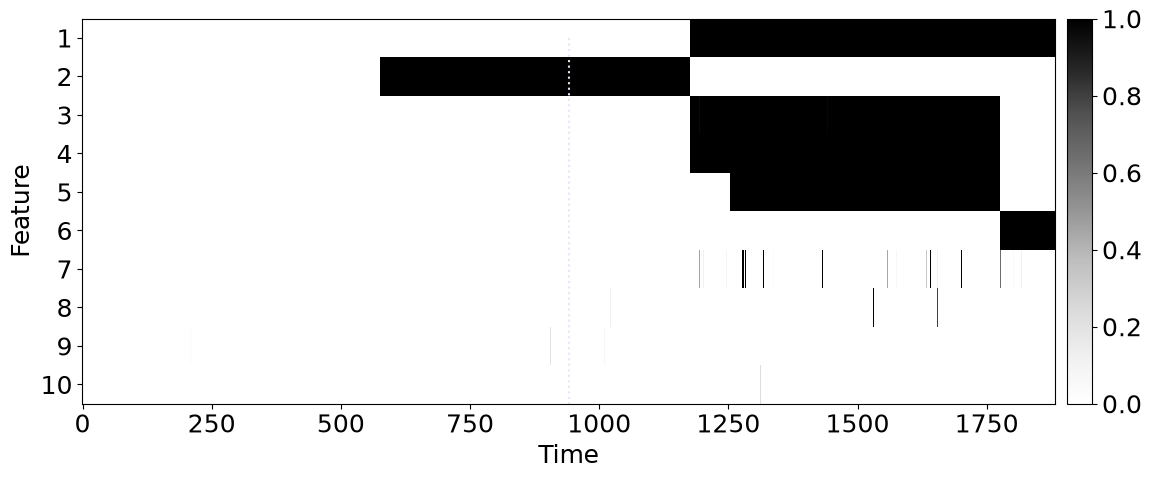

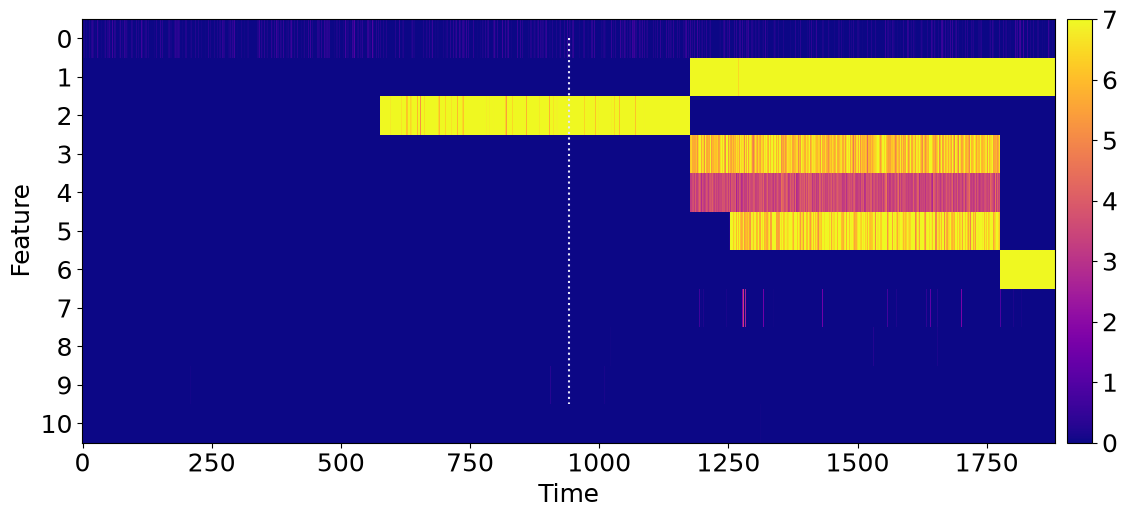

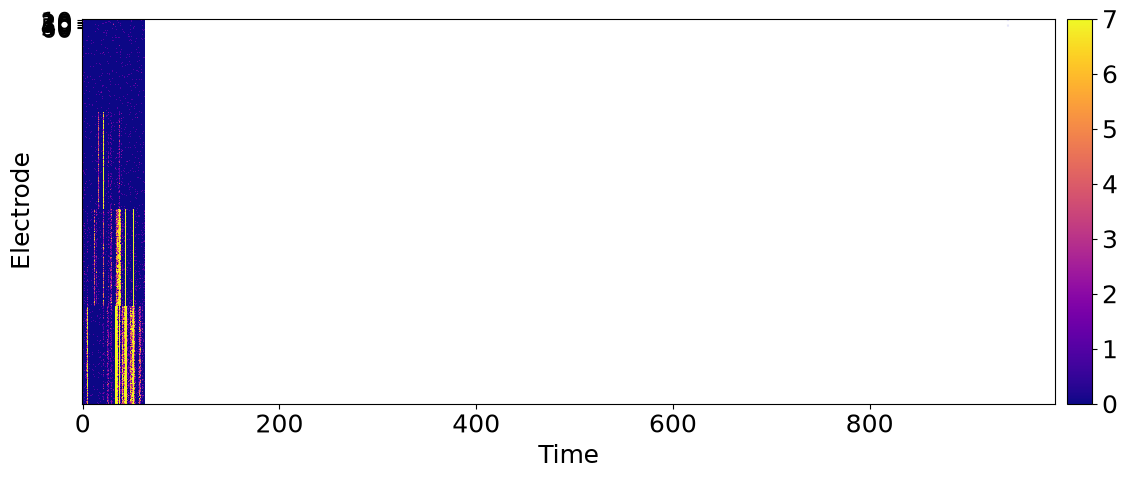

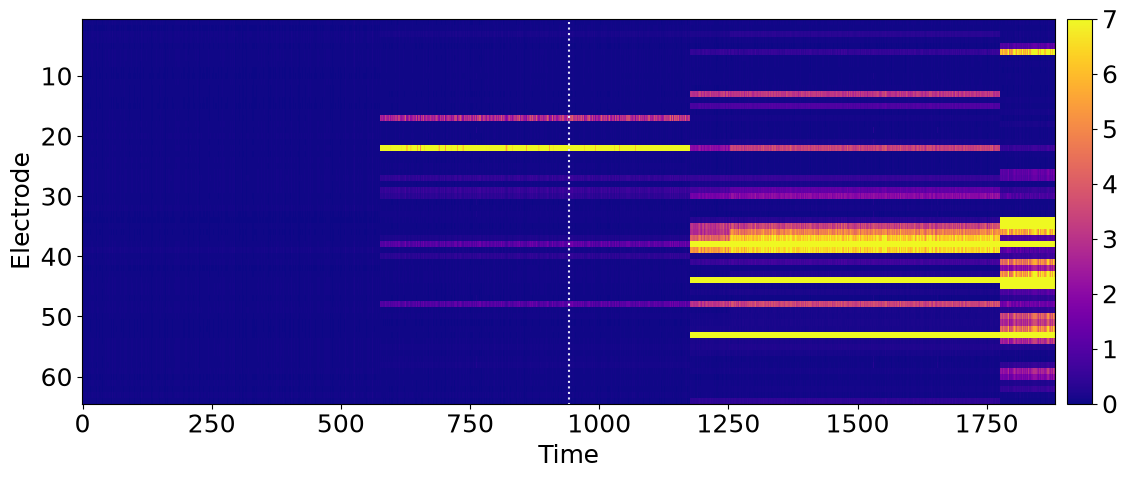

In [20]:
plot(output, model, data, mu_approx.T, "developmental_p3b1", T=T, D=D, K=K, vmax_percentile=95)

In [23]:
theta_learned = torch.abs(model.theta).detach().cpu().numpy()
theta_learned_reordered = theta_learned[sorted_indices]
theta_scale =theta_learned_reordered.max(axis=1) ## changed from max to sum
#theta_scale /=2
z_learned_scaled = np.exp(z_learned_reordered) * theta_scale


theta_theta0_learned_reordered = np.vstack((np.abs(model.theta0.detach().cpu().numpy()), theta_learned_reordered))
h_h0_learned_reordered = np.hstack((np.ones((T,1)), h_learned_reordered))
z_scaled = (np.exp(z_learned_reordered) * theta_theta0_learned_reordered.max(axis=1)[1:(K+1)])
z0_scaled = (np.exp(z0_learned) * theta_theta0_learned_reordered.max(axis=1)[0])
z_z0_learned = np.hstack([z0_scaled, z_scaled])
theta_theta0_scaled = theta_theta0_learned_reordered/theta_theta0_learned_reordered.max(axis=1)[:, None]


In [24]:
h_h0_learned_reordered.shape, z_z0_learned.shape, theta_theta0_scaled.shape

((1200, 11), (1200, 11), (11, 60))

In [25]:
hz_learned_reordered = (h_h0_learned_reordered * z_z0_learned)

In [26]:
mu_s = hz_learned_reordered.T[:, :, None] * theta_theta0_scaled[:, None, :]

In [27]:
mu_s.shape

(11, 1200, 60)

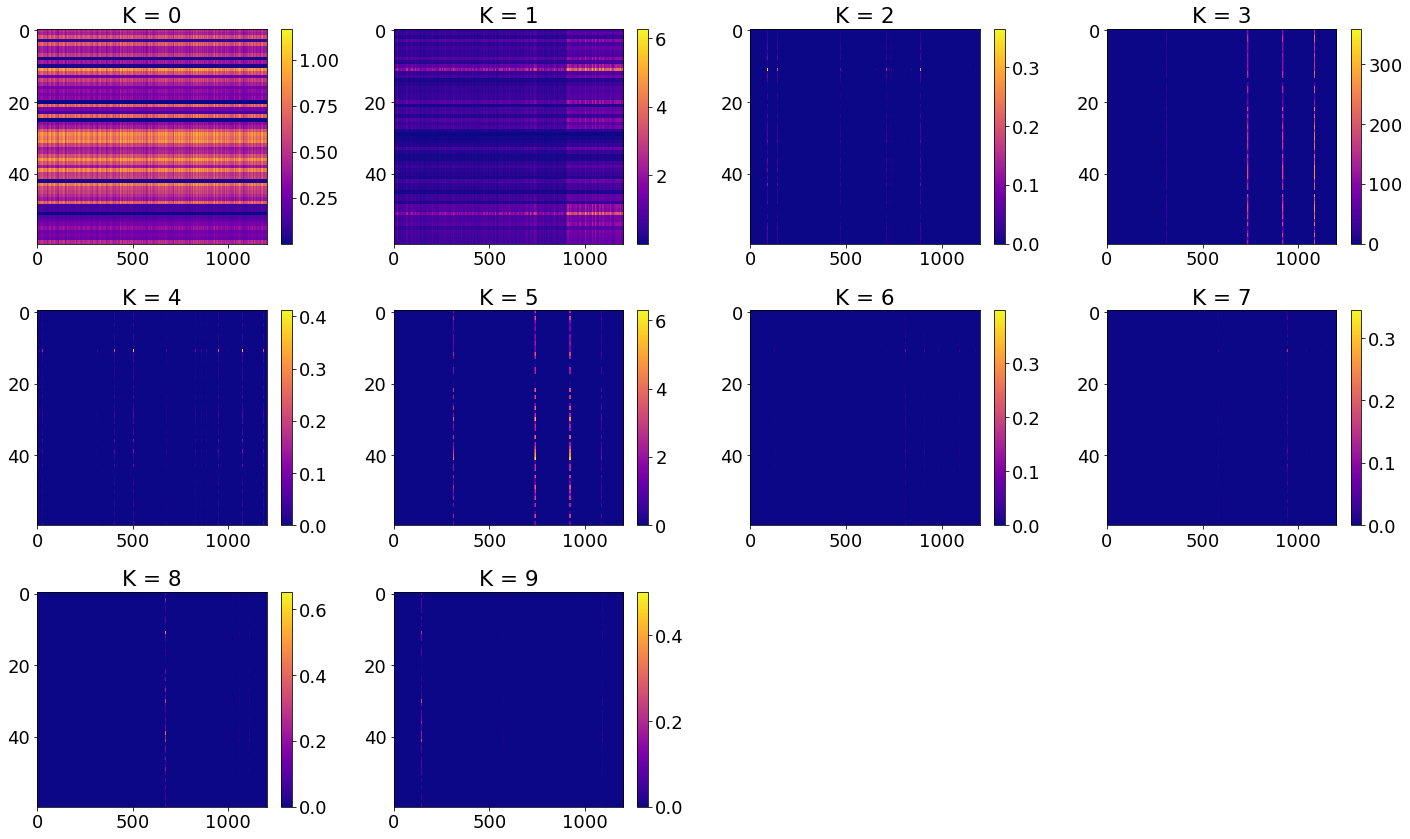

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import math

# choose a grid layout (e.g., as square as possible)
cols = 4
rows = math.ceil(K / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))

axes = np.array(axes).reshape(rows, cols)  # ensure 2D axes

for k in range(K):
    r = k // cols
    c = k % cols
    im = axes[r, c].imshow(mu_s[k].T, aspect='auto', interpolation='none', cmap='plasma')
    axes[r, c].set_title(f"K = {k}")
    fig.colorbar(im, ax=axes[r, c])

# Hide unused axes if K is odd
for i in range(K, rows*cols):
    axes.flat[i].axis("off")

plt.tight_layout()
plt.show()


In [39]:
import numpy as np

def compute_instantaneous_contribution(theta_learned_reordered, 
                                      h_learned_reordered, 
                                      z_learned_reordered):
    """
    Compute instantaneous contribution fraction for each feature at each time point.
    
    Parameters:
    -----------
    theta_learned_reordered : array, shape (K+1, M)
        Learned theta parameters for K+1 features and M electrodes
    h_learned_reordered : array, shape (T, K+1)
        Learned discrete states for T time points and K+1 features
    z_learned_reordered : array, shape (T, K+1)
        Learned continuous latent states for T time points and K+1 features
    
    Returns:
    --------
    contrib : array, shape (T, M, K+1)
        Contribution fraction for each time, electrode, and feature
    """
    T, K_plus_1 = h_learned_reordered.shape
    K_plus_1, M = theta_learned_reordered.shape
    
    # Compute the rate contribution from each feature
    # Shape: (T, K+1, M)
    rate_contributions = (h_learned_reordered[:, :, np.newaxis] * 
                         z_learned_reordered[:, :, np.newaxis] * 
                         theta_learned_reordered[np.newaxis, :, :])
    
    # Total rate for each electrode at each time
    # Shape: (T, M)
    total_rate = np.sum(rate_contributions, axis=1)
    
    # Avoid division by zero
    total_rate = np.where(total_rate == 0, 1e-10, total_rate)
    
    # Contribution fraction
    # Shape: (T, M, K+1)
    contrib = rate_contributions.transpose(0, 2, 1) / total_rate[:, :, np.newaxis]
    unnormalized_contrib = rate_contributions.transpose(0, 2, 1)
    return contrib, unnormalized_contrib


def compute_weighted_contribution(theta_learned_reordered, 
                                  h_learned_reordered, 
                                  z_learned_reordered,
                                  y_observed):
    """
    Compute activity-weighted contribution fraction for each feature.
    
    Parameters:
    -----------
    theta_learned_reordered : array, shape (K+1, M)
        Learned theta parameters for K+1 features and M electrodes
    h_learned_reordered : array, shape (T, K+1)
        Learned discrete states for T time points and K+1 features
    z_learned_reordered : array, shape (T, K+1)
        Learned continuous latent states for T time points and K+1 features
    y_observed : array, shape (T, M)
        Observed spike counts for T time points and M electrodes
    
    Returns:
    --------
    weighted_contrib : array, shape (M, K+1)
        Activity-weighted contribution for each electrode and feature
    """
    # First get instantaneous contributions
    # Shape: (T, M, K+1)
    contrib, unnormalized_contri = compute_instantaneous_contribution(theta_learned_reordered,
                                                h_learned_reordered,
                                                z_learned_reordered)
    
    # Weight by observed counts
    # Shape: (M, K+1)
    numerator = np.sum(y_observed[:, :, np.newaxis] * contrib, axis=0)
    unnormalized_numerator = np.sum(y_observed[:, :, np.newaxis] * unnormalized_contri, axis=0)
    denominator = np.sum(y_observed, axis=0)[:, np.newaxis]
    
    # Avoid division by zero for electrodes with no activity
    denominator = np.where(denominator == 0, 1, denominator)
    
    weighted_contrib = numerator / denominator
    
    return weighted_contrib, unnormalized_numerator / denominator


# Example usage:
# ===============

# Instantaneous contributions
contrib_inst, unnormalized_contrib_inst = compute_instantaneous_contribution(theta_theta0_learned_reordered,
                                                  h_h0_learned_reordered,
                                                  z_z0_learned)

# contrib_inst[t, i, k] gives the fraction of electrode i at time t due to feature k
print(f"Instantaneous contribution shape: {contrib_inst.shape}")  # (T, M, K+1)

# Time-averaged contribution (bonus - simple average over time)
avg_contrib = np.mean(contrib_inst, axis=0)  # Shape: (M, K+1)
print(f"Time-averaged contribution shape: {avg_contrib.shape}")  # (M, K+1)

# Activity-weighted contribution (assuming you have y_observed)
weighted_contrib, unnormalized_weighted_contrib = compute_weighted_contribution(theta_theta0_scaled,
                                                h_h0_learned_reordered,
                                                z_z0_learned,
                                                data.T)

# weighted_contrib[i, k] gives the activity-weighted fraction of electrode i due to feature k
print(f"Activity-weighted contribution shape: {weighted_contrib.shape}")  # (M, K+1)

# To see which feature dominates electrode i:
electrode_idx = 0  # for example
dominant_feature = np.argmax(weighted_contrib[electrode_idx, :])
print(f"Electrode {electrode_idx} is most associated with feature {dominant_feature}")
print(f"Contribution fractions: {weighted_contrib[electrode_idx, :]}")

Instantaneous contribution shape: (1200, 60, 11)
Time-averaged contribution shape: (60, 11)
Activity-weighted contribution shape: (60, 11)
Electrode 0 is most associated with feature 3
Contribution fractions: [1.34266641e-01 1.47830317e-01 6.81401454e-05 7.06614130e-01
 6.10230873e-06 1.07856065e-02 5.72188416e-05 1.13318442e-04
 8.26467164e-05 1.75816874e-04 6.14246740e-08]


In [ ]:
rate_contributions = (h_h0_learned_reordered[:, :, np.newaxis] * 
                        z_z0_learned[:, :, np.newaxis] * 
                        theta_theta0_scaled[np.newaxis, :, :])

# Total rate for each electrode at each time
# Shape: (T, M)
total_rate = np.sum(rate_contributions, axis=1)

# Avoid division by zero
total_rate = np.where(total_rate == 0, 1e-10, total_rate)

# Contribution fraction
# Shape: (T, M, K+1)
contrib = rate_contributions.transpose(0, 2, 1) / total_rate[:, :, np.newaxis]

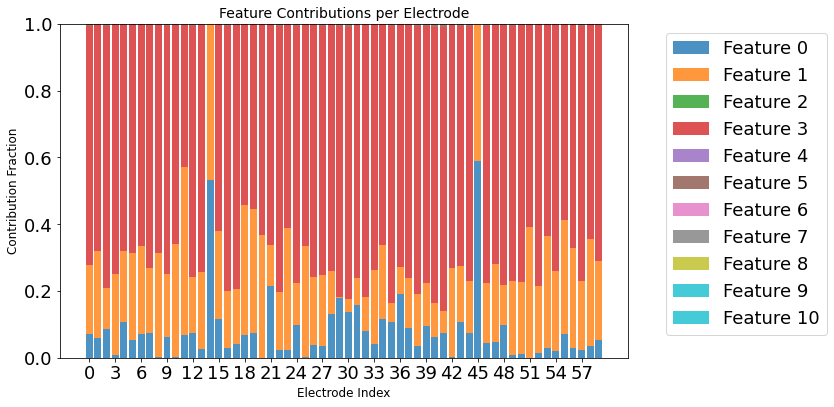

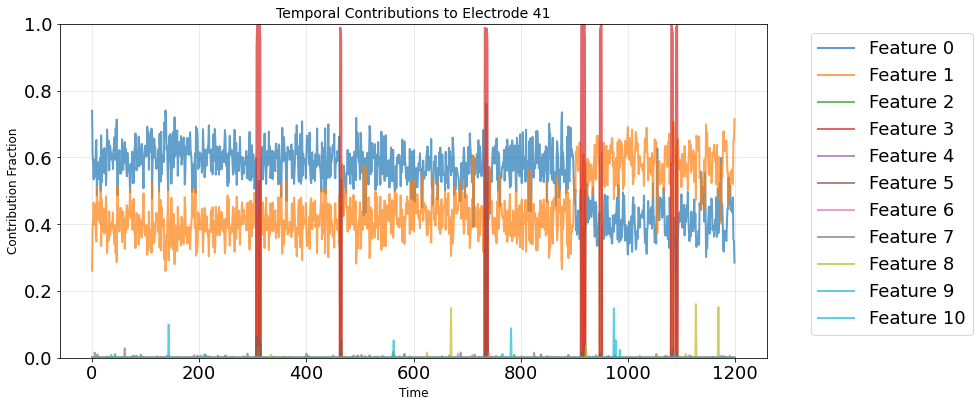

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. HEATMAP: Overall feature-electrode associations
# ====================================================
def plot_contribution_heatmap(weighted_contrib, feature_names=None, 
                             electrode_names=None, title="Feature-Electrode Associations",
                             y_label_frequency=5):
    """
    Heatmap showing which features drive which electrodes.
    
    Parameters:
    -----------
    weighted_contrib : array, shape (M, K+1)
        Activity-weighted contribution for each electrode and feature
    y_label_frequency : int
        Show every Nth electrode label (default: 5)
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    K_plus_1 = weighted_contrib.shape[1]
    M = weighted_contrib.shape[0]
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(K_plus_1)]
    if electrode_names is None:
        electrode_names = [f'Electrode {i}' for i in range(M)]
    
    sns.heatmap(weighted_contrib, 
                xticklabels=feature_names,
                yticklabels=electrode_names,
                cmap='YlOrRd',
                annot=True if M <= 20 else False,
                fmt='.2f',
                cbar_kws={'label': 'Contribution Fraction'},
                ax=ax)
    
    # Show only every Nth electrode label
    yticks = ax.get_yticks()
    yticklabels = [label.get_text() if i % y_label_frequency == 0 else '' 
                   for i, label in enumerate(ax.get_yticklabels())]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    
    ax.set_xlabel('Features', fontsize=12)
    ax.set_ylabel('Electrodes', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    return fig


# 2. STACKED BAR CHART: Feature composition per electrode
# ========================================================
def plot_stacked_contributions(weighted_contrib, feature_names=None,
                              electrode_subset=None, figsize=(12, 6)):
    """
    Stacked bar chart showing feature contributions to each electrode.
    """
    K = weighted_contrib.shape[1]
    M = weighted_contrib.shape[0]
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(K)]
    
    # Select subset of electrodes if there are too many
    if electrode_subset is None:
        if M > 64:
            electrode_subset = np.arange(0, M, M // 64)  # Sample evenly
        else:
            electrode_subset = np.arange(M)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create stacked bars
    bottom = np.zeros(len(electrode_subset))
    colors = plt.cm.tab10(np.linspace(0, 1, K))
    
    for k in range(K):
        values = weighted_contrib[electrode_subset, k]
        ax.bar(range(len(electrode_subset)), values, bottom=bottom, 
               label=feature_names[k], color=colors[k], alpha=0.8)
        bottom += values
    max_labels = 20
    step = max(1, len(electrode_subset) // max_labels)
    xticks = np.arange(0, len(electrode_subset), step)
    ax.set_xlabel('Electrode Index', fontsize=12)
    ax.set_ylabel('Contribution Fraction', fontsize=12)
    ax.set_title('Feature Contributions per Electrode', fontsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels(electrode_subset[xticks])
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim([0, 1])
    plt.tight_layout()
    return fig


# 3. TEMPORAL DYNAMICS: How contributions evolve over time
# =========================================================
def plot_temporal_contributions(contrib_inst, electrode_idx, 
                               feature_names=None, time_range=None):
    """
    Line plot showing how different features contribute to a specific electrode over time.
    
    Parameters:
    -----------
    contrib_inst : array, shape (T, M, K+1)
        Instantaneous contributions
    electrode_idx : int
        Which electrode to visualize
    """
    T, M, K = contrib_inst.shape
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(K)]
    
    if time_range is None:
        time_range = (0, T) # Show first 500 timepoints by default
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    time_idx = np.arange(time_range[0], time_range[1])
    colors = plt.cm.tab10(np.linspace(0, 1, K))
    
    for k in range(K):
        ax.plot(time_idx, contrib_inst[time_idx, electrode_idx, k], 
               label=feature_names[k], color=colors[k], linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Contribution Fraction', fontsize=12)
    ax.set_title(f'Temporal Contributions to Electrode {electrode_idx}', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig


contrib_inst, unnormalized_contrib_inst = compute_instantaneous_contribution(theta_theta0_learned_reordered,
                                                    h_h0_learned_reordered,
                                                    z_z0_learned)

weighted_contrib, unnormalized_weighted_contrib = compute_weighted_contribution(theta_theta0_learned_reordered,
                                                    h_h0_learned_reordered,
                                                    z_z0_learned,
                                                    data.T)

# Create visualizations
# You can adjust y_label_frequency to control how many electrode labels are shown
fig2 = plot_stacked_contributions(weighted_contrib)
fig3 = plot_temporal_contributions(contrib_inst, electrode_idx=41)

plt.show()


Most Active Electrode per Feature (Time-Averaged):
  Feature 1: Electrode 29 (contrib=0.955)
  Feature 2: Electrode 51 (contrib=0.973)
  Feature 3: Electrode 31 (contrib=0.000)
  Feature 4: Electrode 36 (contrib=0.027)
  Feature 5: Electrode 29 (contrib=0.001)
  Feature 6: Electrode 41 (contrib=0.001)
  Feature 7: Electrode 39 (contrib=0.000)
  Feature 8: Electrode 31 (contrib=0.000)
  Feature 9: Electrode 30 (contrib=0.001)
  Feature 10: Electrode 30 (contrib=0.000)

Most Active Electrode per Feature (Activity-Weighted):
  Feature 1: Electrode 45 (contrib=0.589)
  Feature 2: Electrode 11 (contrib=0.502)
  Feature 3: Electrode 14 (contrib=0.000)
  Feature 4: Electrode 41 (contrib=0.850)
  Feature 5: Electrode 14 (contrib=0.000)
  Feature 6: Electrode 41 (contrib=0.011)
  Feature 7: Electrode 11 (contrib=0.000)
  Feature 8: Electrode 45 (contrib=0.000)
  Feature 9: Electrode 41 (contrib=0.000)
  Feature 10: Electrode 30 (contrib=0.000)


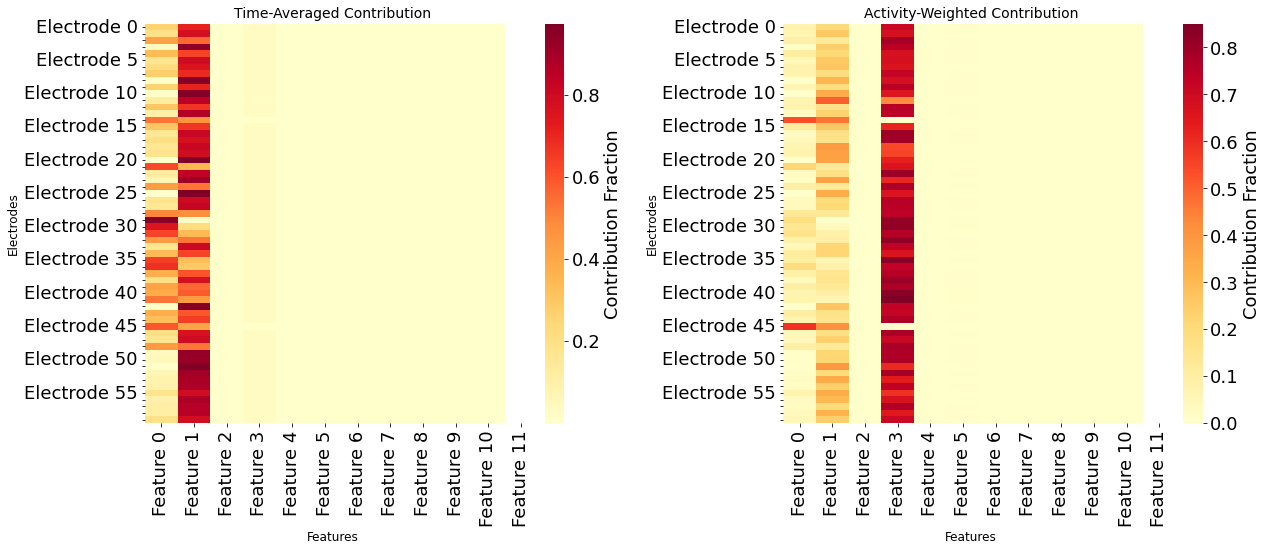

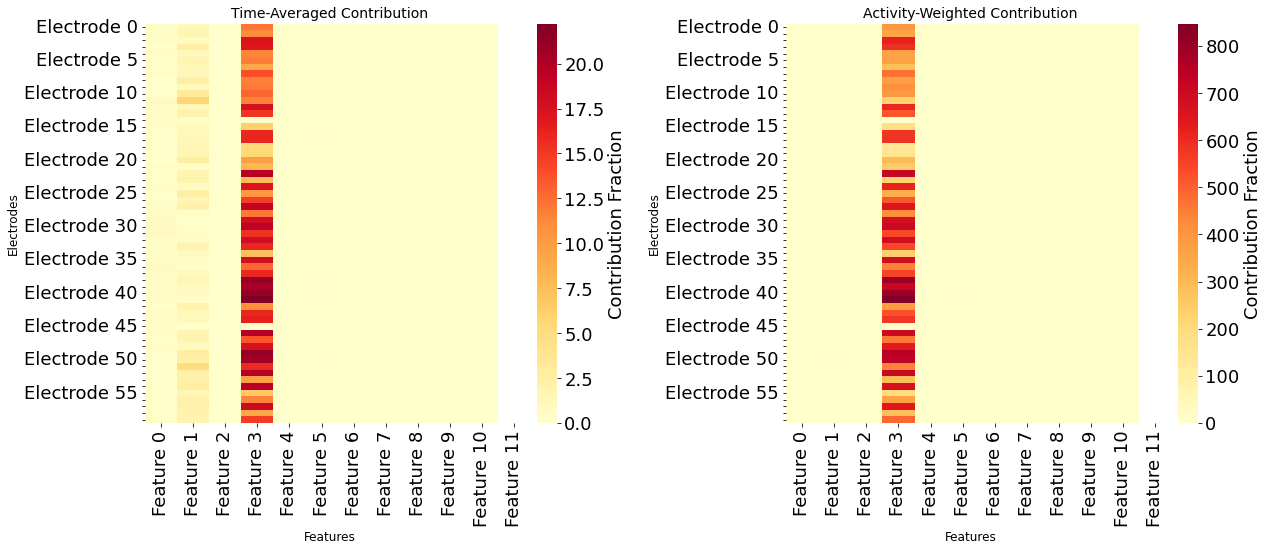

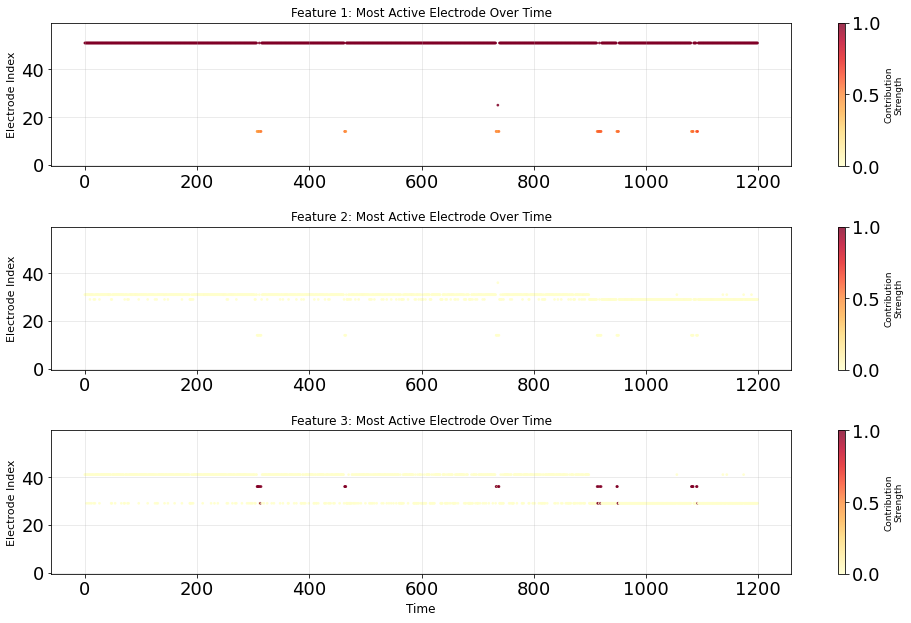

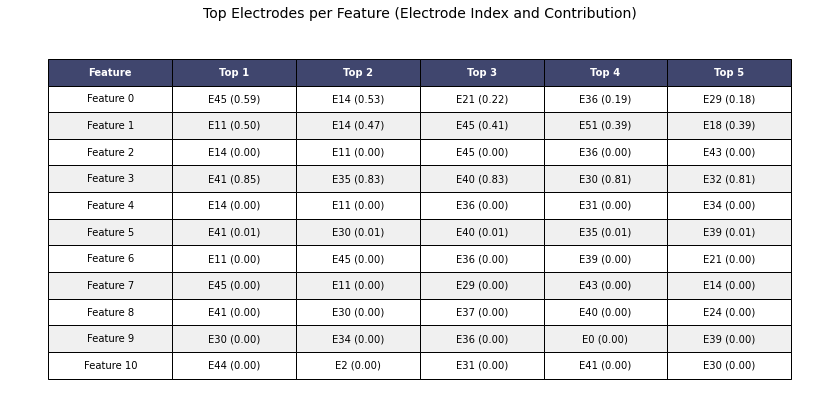

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 8. COMPARISON: Time-averaged vs Activity-weighted
# ==================================================
def plot_contribution_comparison(contrib_inst, weighted_contrib, feature_names=None,
                                y_label_frequency=5):
    """
    Side-by-side comparison of time-averaged and activity-weighted contributions.
    """
    avg_contrib = np.mean(contrib_inst, axis=0)
    
    M, K = avg_contrib.shape
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(K + 1)]
    
    electrode_names = [f'Electrode {i}' for i in range(M)]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Time-averaged
    sns.heatmap(avg_contrib, 
                xticklabels=feature_names,
                yticklabels=electrode_names,
                cmap='YlOrRd',
                annot=True if M <= 20 else False,
                fmt='.2f',
                cbar_kws={'label': 'Contribution Fraction'},
                ax=ax1)
    ax1.set_title('Time-Averaged Contribution', fontsize=14)
    ax1.set_xlabel('Features', fontsize=12)
    ax1.set_ylabel('Electrodes', fontsize=12)
    
    # Activity-weighted
    sns.heatmap(weighted_contrib, 
                xticklabels=feature_names,
                yticklabels=electrode_names,
                cmap='YlOrRd',
                annot=True if M <= 20 else False,
                fmt='.2f',
                cbar_kws={'label': 'Contribution Fraction'},
                ax=ax2)
    ax2.set_title('Activity-Weighted Contribution', fontsize=14)
    ax2.set_xlabel('Features', fontsize=12)
    ax2.set_ylabel('Electrodes', fontsize=12)
    
    # Apply y-axis label frequency to both
    for ax in [ax1, ax2]:
        yticks = ax.get_yticks()
        yticklabels = [label.get_text() if i % y_label_frequency == 0 else '' 
                       for i, label in enumerate(ax.get_yticklabels())]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)
    
    plt.tight_layout()
    return fig


# FUNCTIONS TO FIND MOST ACTIVE ELECTRODE PER FEATURE
# ====================================================

def find_most_active_electrode_timeavg(contrib_inst):
    """
    Find the most active electrode for each feature based on time-averaged contribution.
    
    Parameters:
    -----------
    contrib_inst : array, shape (T, M, K+1)
        Instantaneous contributions
    
    Returns:
    --------
    most_active_electrodes : array, shape (K+1,)
        Index of most active electrode for each feature
    contribution_values : array, shape (K+1,)
        Average contribution value for the most active electrode
    """
    # Average over time: (M, K+1)
    avg_contrib = np.mean(contrib_inst, axis=0)
    
    # For each feature, find electrode with highest average contribution
    most_active_electrodes = np.argmax(avg_contrib, axis=0)
    contribution_values = np.max(avg_contrib, axis=0)
    
    return most_active_electrodes, contribution_values


def find_most_active_electrode_weighted(weighted_contrib):
    """
    Find the most active electrode for each feature based on activity-weighted contribution.
    
    Parameters:
    -----------
    weighted_contrib : array, shape (M, K+1)
        Activity-weighted contribution
    
    Returns:
    --------
    most_active_electrodes : array, shape (K+1,)
        Index of most active electrode for each feature
    contribution_values : array, shape (K+1,)
        Weighted contribution value for the most active electrode
    """
    most_active_electrodes = np.argmax(weighted_contrib, axis=0)
    contribution_values = np.max(weighted_contrib, axis=0)
    
    return most_active_electrodes, contribution_values


def find_most_active_electrode_temporal(contrib_inst):
    """
    Find the most active electrode for each feature at each time point.
    
    Parameters:
    -----------
    contrib_inst : array, shape (T, M, K+1)
        Instantaneous contributions
    
    Returns:
    --------
    most_active_electrodes_time : array, shape (T, K+1)
        Index of most active electrode for each feature at each time
    contribution_values_time : array, shape (T, K+1)
        Contribution value for the most active electrode at each time
    """
    T, M, K = contrib_inst.shape
    
    # For each time and feature, find electrode with highest contribution
    most_active_electrodes_time = np.argmax(contrib_inst, axis=1)
    contribution_values_time = np.max(contrib_inst, axis=1)
    
    return most_active_electrodes_time, contribution_values_time


def get_top_k_electrodes_per_feature(weighted_contrib, k=5):
    """
    Get the top k electrodes for each feature.
    
    Parameters:
    -----------
    weighted_contrib : array, shape (M, K+1)
        Activity-weighted contribution
    k : int
        Number of top electrodes to return
    
    Returns:
    --------
    top_k_electrodes : array, shape (K+1, k)
        Indices of top k electrodes for each feature
    top_k_values : array, shape (K+1, k)
        Contribution values for top k electrodes
    """
    M, K = weighted_contrib.shape
    k = min(k, M)  # Don't request more than available
    
    # Sort electrodes by contribution for each feature
    top_k_electrodes = np.argsort(weighted_contrib, axis=0)[-k:][::-1].T
    top_k_values = np.sort(weighted_contrib, axis=0)[-k:][::-1].T
    
    return top_k_electrodes, top_k_values


# VISUALIZATION: Most active electrodes
# ======================================

def plot_most_active_electrodes(weighted_contrib, feature_names=None):
    """
    Bar plot showing which electrode is most active for each feature.
    """
    most_active, values = find_most_active_electrode_weighted(weighted_contrib)
    
    K = len(most_active)
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(K + 1)]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, K))
    
    # Plot 1: Most active electrode index
    ax1.bar(range(K), most_active, color=colors, alpha=0.7)
    ax1.set_xlabel('Features', fontsize=12)
    ax1.set_ylabel('Most Active Electrode Index', fontsize=12)
    ax1.set_title('Most Active Electrode per Feature', fontsize=14)
    ax1.set_xticks(range(K))
    ax1.set_xticklabels(feature_names, rotation=45, ha='right')
    ax1.grid(alpha=0.3, axis='y')
    
    # Plot 2: Contribution strength
    ax2.bar(range(K), values, color=colors, alpha=0.7)
    ax2.set_xlabel('Features', fontsize=12)
    ax2.set_ylabel('Contribution Strength', fontsize=12)
    ax2.set_title('Strength of Most Active Electrode', fontsize=14)
    ax2.set_xticks(range(K))
    ax2.set_xticklabels(feature_names, rotation=45, ha='right')
    ax2.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig


def plot_temporal_most_active(contrib_inst, feature_subset=None, 
                              feature_names=None, time_range=None):
    """
    Plot which electrode is most active for selected features over time.
    
    Parameters:
    -----------
    contrib_inst : array, shape (T, M, K+1)
        Instantaneous contributions
    feature_subset : list or None
        Which features to plot (if None, plot all)
    """
    T, M, K = contrib_inst.shape
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(1, K + 1)]
    
    if feature_subset is None:
        feature_subset = range(K)
    
    if time_range is None:
        time_range = (0, T)
    
    most_active_time, values_time = find_most_active_electrode_temporal(contrib_inst)
    
    n_features = len(feature_subset)
    fig, axes = plt.subplots(n_features, 1, figsize=(14, 3*n_features))
    
    if n_features == 1:
        axes = [axes]
    
    time_idx = np.arange(time_range[0], time_range[1])
    
    for idx, feature_k in enumerate(feature_subset):
        ax = axes[idx]
        
        # Plot which electrode is most active
        ax.plot(time_idx, most_active_time[time_idx, feature_k], 
               linewidth=1, alpha=0.7)
        ax.set_ylabel('Electrode Index', fontsize=11)
        ax.set_title(f'{feature_names[feature_k]}: Most Active Electrode Over Time', 
                    fontsize=12)
        ax.grid(alpha=0.3)
        
        if idx == n_features - 1:
            ax.set_xlabel('Time', fontsize=12)
    
    plt.tight_layout()
    return fig


def plot_top_electrodes_table(weighted_contrib, k=5, feature_names=None):
    """
    Create a visual table showing top k electrodes for each feature.
    """
    top_k_elec, top_k_vals = get_top_k_electrodes_per_feature(weighted_contrib, k=k)
    
    K, k_actual = top_k_elec.shape
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(K)]
    
    fig, ax = plt.subplots(figsize=(12, max(6, K * 0.5)))
    ax.axis('tight')
    ax.axis('off')
    
    # Create table data
    table_data = []
    for feat_idx in range(K):
        row = [feature_names[feat_idx]]
        for j in range(k_actual):
            row.append(f"E{top_k_elec[feat_idx, j]} ({top_k_vals[feat_idx, j]:.2f})")
        table_data.append(row)
    
    columns = ['Feature'] + [f'Top {i+1}' for i in range(k_actual)]
    
    table = ax.table(cellText=table_data, colLabels=columns,
                    cellLoc='center', loc='center',
                    colWidths=[0.15] + [0.15]*k_actual)
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style header
    for i in range(len(columns)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data) + 1):
        for j in range(len(columns)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f0f0f0')
    
    plt.title('Top Electrodes per Feature (Electrode Index and Contribution)', 
             fontsize=14, pad=20)
    plt.tight_layout()
    return fig

def plot_temporal_most_active_colored(contrib_inst, feature_subset=None, 
                                     feature_names=None, time_range=None,
                                     markersize=3):
    """
    Scatter plot with points colored by contribution strength.
    """
    T, M, K = contrib_inst.shape
    
    if feature_names is None:
        feature_names = [f'Feature {k}' for k in range(K)]
    
    if feature_subset is None:
        feature_subset = range(K)
    
    if time_range is None:
        time_range = (0, T)
    
    most_active_time, values_time = find_most_active_electrode_temporal(contrib_inst)
    
    n_features = len(feature_subset)
    fig, axes = plt.subplots(n_features, 1, figsize=(14, 3*n_features))
    
    if n_features == 1:
        axes = [axes]
    
    time_idx = np.arange(time_range[0], time_range[1])
    
    for idx, feature_k in enumerate(feature_subset):
        ax = axes[idx]
        
        # Color by contribution strength
        scatter = ax.scatter(time_idx, 
                           most_active_time[time_idx, feature_k],
                           c=values_time[time_idx, feature_k],
                           s=markersize, 
                           cmap='YlOrRd',
                           vmin=0, vmax=1,
                           alpha=0.8)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Contribution\nStrength', fontsize=9)
        
        ax.set_ylabel('Electrode Index', fontsize=11)
        ax.set_title(f'{feature_names[feature_k]}: Most Active Electrode Over Time', 
                    fontsize=12)
        ax.grid(alpha=0.3)
        ax.set_ylim(-0.5, M-0.5)
        
        if idx == n_features - 1:
            ax.set_xlabel('Time', fontsize=12)
    
    plt.tight_layout()
    return fig

# 8. Comparison of time-averaged vs activity-weighted
fig8 = plot_contribution_comparison(contrib_inst, weighted_contrib, y_label_frequency=5)
fig8_unnormalized = plot_contribution_comparison(unnormalized_contrib_inst, unnormalized_weighted_contrib, y_label_frequency=5)


# 10. Temporal dynamics of most active electrode
fig10_colored = plot_temporal_most_active_colored(contrib_inst, feature_subset=[1, 2, 3])

# 11. Table of top electrodes
fig11 = plot_top_electrodes_table(weighted_contrib, k=5)

# ANALYZE most active electrodes
most_active_avg, values_avg = find_most_active_electrode_timeavg(contrib_inst)
most_active_weighted, values_weighted = find_most_active_electrode_weighted(weighted_contrib)

print("\nMost Active Electrode per Feature (Time-Averaged):")
for k in range(K):
    print(f"  Feature {k+1}: Electrode {most_active_avg[k]} (contrib={values_avg[k]:.3f})")

print("\nMost Active Electrode per Feature (Activity-Weighted):")
for k in range(K):
    print(f"  Feature {k+1}: Electrode {most_active_weighted[k]} (contrib={values_weighted[k]:.3f})")

plt.show()

In [33]:
contrib_inst.shape, weighted_contrib.shape

((1200, 60, 11), (60, 11))

In [34]:
avg_contrib.shape

(60, 11)

Computing electrode contributions to features...
FEATURE LOCALIZATION SUMMARY

Feature 0:
----------------------------------------------------------------------
  Gini coefficient: 0.320 (0=uniform, 1=concentrated)

  Top 5 contributing electrodes:
    1. Electrode 11: 3.40%
    2. Electrode 36: 3.31%
    3. Electrode 31: 3.25%
    4. Electrode 29: 3.23%
    5. Electrode 39: 3.15%

  19 electrodes account for 50% of contribution
  35 electrodes account for 80% of contribution

Feature 1:
----------------------------------------------------------------------
  Gini coefficient: 0.349 (0=uniform, 1=concentrated)

  Top 5 contributing electrodes:
    1. Electrode 11: 6.09%
    2. Electrode 51: 5.36%
    3. Electrode 10: 3.42%
    4. Electrode 49: 3.01%
    5. Electrode 20: 2.99%

  17 electrodes account for 50% of contribution
  34 electrodes account for 80% of contribution

Feature 2:
----------------------------------------------------------------------
  Gini coefficient: 0.463 (0=unif

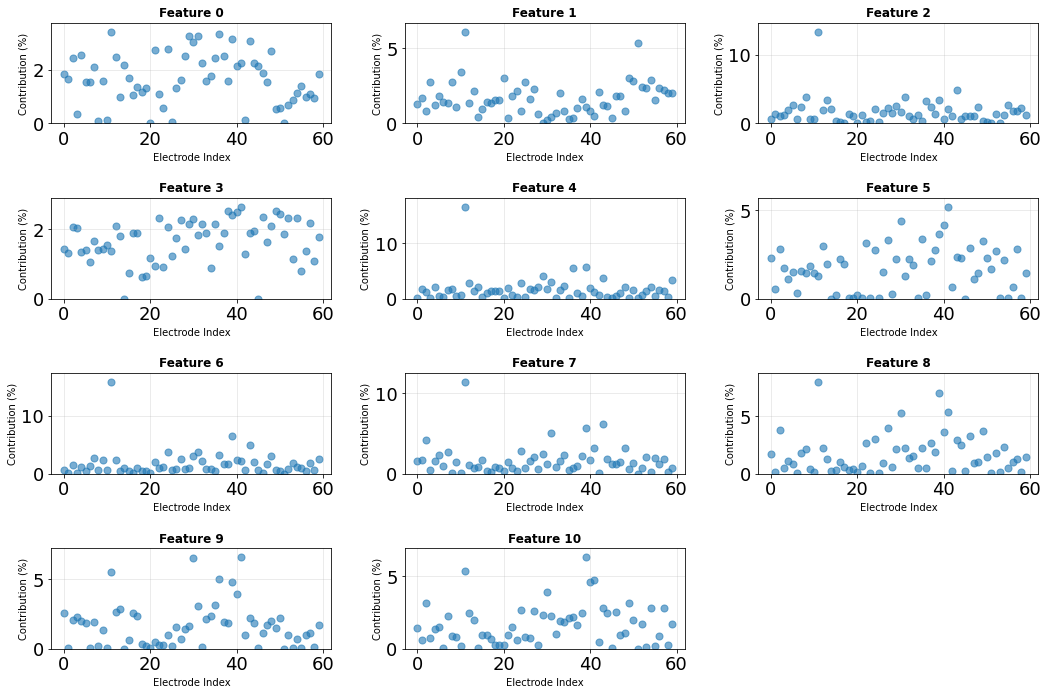

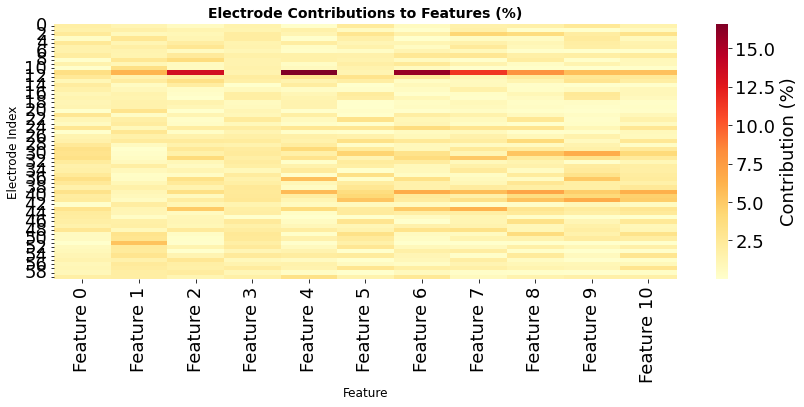


Done!


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_electrode_to_feature_contributions(theta, h, z, include_baseline=True):
    """
    Compute the percentage contribution of each electrode to each feature.
    
    Parameters:
    -----------
    theta : array-like, shape (K+1, M)
        Feature loadings, where K is number of learned features and M is number of electrodes
        theta[k, i] represents the loading of feature k on electrode i
    h : array-like, shape (T, K+1)
        Feature activations over time, where T is number of time points
        h[t, k] represents the activation of feature k at time t
        Note: h[:, 0] should be all ones (baseline)
    z : array-like, shape (T, K+1)
        Continuous modulations over time
        The model uses exp(z[t, k]) as the multiplicative factor
    include_baseline : bool, default=True
        Whether to include feature 0 (baseline) in the analysis
        
    Returns:
    --------
    contributions : array, shape (K+1, M) or (K, M)
        contributions[k, i] = percentage contribution of electrode i to feature k
        Each row sums to 1.0 (or 100%)
    """
    theta = np.array(theta)
    h = np.array(h)
    z = np.array(z)
    
    K_plus_1, M = theta.shape
    T = h.shape[0]
    
    # Determine which features to include
    if include_baseline:
        feature_indices = range(K_plus_1)
    else:
        feature_indices = range(1, K_plus_1)
    
    # Initialize output
    n_features = len(feature_indices)
    contributions = np.zeros((n_features, M))
    
    # Compute contributions for each feature
    for idx, k in enumerate(feature_indices):
        # Compute numerator: sum_t theta[k,i] * h[t,k] * exp(z[t,k]) for each electrode i
        exp_z = z[:, k]  # shape (T,)
        h_k = h[:, k]  # shape (T,)
        
        # For each electrode i: sum over time
        for i in range(M):
            numerator = np.sum(theta[k, i] * h_k * exp_z)
            contributions[idx, i] = numerator
        
        # Normalize by total contribution across all electrodes for this feature
        total_contribution = np.sum(contributions[idx, :])
        if total_contribution > 0:
            contributions[idx, :] /= total_contribution
        else:
            # If feature has zero contribution, set uniform distribution
            contributions[idx, :] = 1.0 / M
    
    return contributions


def plot_electrode_contributions_scatter(contributions, feature_labels=None, 
                                         figsize=(15, 10), save_path=None):
    """
    Create scatter plots showing electrode contributions for each feature.
    One subplot per feature.
    
    Parameters:
    -----------
    contributions : array, shape (n_features, M)
        Output from compute_electrode_to_feature_contributions
    feature_labels : list of str, optional
        Labels for each feature (e.g., ['Feature 0', 'Feature 1', ...])
    figsize : tuple, default=(15, 10)
        Figure size
    save_path : str, optional
        Path to save the figure
    """
    n_features, M = contributions.shape
    
    # Create feature labels if not provided
    if feature_labels is None:
        feature_labels = [f'Feature {k}' for k in range(n_features)]
    
    # Determine subplot layout
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_features > 1 else [axes]
    
    electrode_indices = np.arange(M)
    
    for idx in range(n_features):
        ax = axes[idx]
        
        # Plot as dots
        ax.scatter(electrode_indices, contributions[idx, :] * 100, 
                  alpha=0.6, s=50)
        
        ax.set_xlabel('Electrode Index', fontsize=10)
        ax.set_ylabel('Contribution (%)', fontsize=10)
        ax.set_title(feature_labels[idx], fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, max(contributions[idx, :] * 100) * 1.1)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig


def plot_electrode_contributions_heatmap(contributions, feature_labels=None,
                                         electrode_labels=None, figsize=(12, 6),
                                         save_path=None):
    """
    Create a heatmap showing electrode contributions to features.
    
    Parameters:
    -----------
    contributions : array, shape (n_features, M)
        Output from compute_electrode_to_feature_contributions
    feature_labels : list of str, optional
        Labels for each feature (rows)
    electrode_labels : list of str, optional
        Labels for each electrode (columns)
    figsize : tuple, default=(12, 6)
        Figure size
    save_path : str, optional
        Path to save the figure
    """
    n_features, M = contributions.shape
    
    # Create labels if not provided
    if feature_labels is None:
        feature_labels = [f'Feature {k}' for k in range(n_features)]
    if electrode_labels is None:
        electrode_labels = [f'{i}' for i in range(M)]
    
    # Convert to percentage
    contributions_pct = contributions * 100
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(contributions_pct.T, annot=False, fmt='.1f', 
                cmap='YlOrRd', cbar_kws={'label': 'Contribution (%)'},
                yticklabels=electrode_labels, xticklabels=feature_labels,
                ax=ax)
    
    ax.set_ylabel('Electrode Index', fontsize=12)
    ax.set_xlabel('Feature', fontsize=12)
    ax.set_title('Electrode Contributions to Features (%)', fontsize=14, fontweight='bold')
    
    # Adjust x-axis labels
    if M > 30:
        # Show every nth label to avoid crowding
        n_skip = M // 30
        for idx, label in enumerate(ax.get_yticklabels()):
            if idx % n_skip != 0:
                label.set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig


def summarize_feature_localization(contributions, feature_labels=None, top_k=5):
    """
    Print summary statistics about feature localization.
    
    Parameters:
    -----------
    contributions : array, shape (n_features, M)
        Output from compute_electrode_to_feature_contributions
    feature_labels : list of str, optional
        Labels for each feature
    top_k : int, default=5
        Number of top electrodes to display for each feature
    """
    n_features, M = contributions.shape
    
    if feature_labels is None:
        feature_labels = [f'Feature {k}' for k in range(n_features)]
    
    print("=" * 70)
    print("FEATURE LOCALIZATION SUMMARY")
    print("=" * 70)
    
    for idx in range(n_features):
        print(f"\n{feature_labels[idx]}:")
        print("-" * 70)
        
        # Compute Gini coefficient as measure of concentration
        sorted_contrib = np.sort(contributions[idx, :])
        n = len(sorted_contrib)
        index = np.arange(1, n + 1)
        gini = (2 * np.sum(index * sorted_contrib)) / (n * np.sum(sorted_contrib)) - (n + 1) / n
        
        print(f"  Gini coefficient: {gini:.3f} (0=uniform, 1=concentrated)")
        
        # Top contributing electrodes
        top_indices = np.argsort(contributions[idx, :])[-top_k:][::-1]
        print(f"\n  Top {top_k} contributing electrodes:")
        for rank, elec_idx in enumerate(top_indices, 1):
            pct = contributions[idx, elec_idx] * 100
            print(f"    {rank}. Electrode {elec_idx}: {pct:.2f}%")
        
        # Cumulative contribution
        cumsum = np.cumsum(np.sort(contributions[idx, :])[::-1])
        n_electrodes_50pct = np.searchsorted(cumsum, 0.5) + 1
        n_electrodes_80pct = np.searchsorted(cumsum, 0.8) + 1
        
        print(f"\n  {n_electrodes_50pct} electrodes account for 50% of contribution")
        print(f"  {n_electrodes_80pct} electrodes account for 80% of contribution")



    
# Compute contributions
print("Computing electrode contributions to features...")
contributions = compute_electrode_to_feature_contributions(theta_theta0_learned_reordered, h_h0_learned_reordered, z_z0_learned, include_baseline=True)

# Print summary
feature_labels = [f'Feature {k}' for k in range(K+1)]
summarize_feature_localization(contributions, feature_labels)

# Create visualizations
print("\nCreating visualizations...")
plot_electrode_contributions_scatter(contributions, feature_labels)
plot_electrode_contributions_heatmap(contributions, feature_labels)

print("\nDone!")

In [30]:
z_h_learned = z_learned_scaled * h_learned_reordered

z_h_diff = z_h_learned[1:]-z_h_learned[:T-1]

In [30]:
K_prime = 3
feature_names = [f'Feature_{k+1}' for k in range(K_prime)]
diff_df = pd.DataFrame(z_h_diff[:, :K_prime], columns=feature_names)

In [28]:
K_prime = 5

In [29]:
import numpy as np
import pandas as pd
original_data = pd.DataFrame(z_h_learned[:, :K_prime], columns=[f'Feature_{k+1}' for k in range(K_prime)])

break_point = 900

def quantify_treatment_effect(series: pd.Series, break_point: int) -> dict:
    """Calculates magnitude and variability metrics for pre- and post-treatment regimes."""
    
    if break_point <= 0 or break_point >= len(series):
        raise ValueError("Break point is invalid for the series length.")

    # 1. Define Regimes (R1 = Baseline, R2 = Treatment)
    R1 = series.iloc[:break_point]
    R2 = series.iloc[break_point:]

    # 2. Calculate Metrics
    results = {}
    
    R1_mean_abs = np.abs(R1).mean()
    R2_mean_abs = np.abs(R2).mean()
    R1_std = R1.std()
    R2_std = R2.std()
    
    # Absolute Magnitude
    results['Mean Abs Mag (Baseline)'] = R1_mean_abs
    results['Mean Abs Mag (Treatment)'] = R2_mean_abs
    results['Magnitude Ratio (B/T)'] = R1_mean_abs / R2_mean_abs

    # Absolute Variability
    results['Std Dev (Baseline)'] = R1_std
    results['Std Dev (Treatment)'] = R2_std
    results['Std Dev Ratio (B/T)'] = R1_std / R2_std
    
    # Relative Variability (CV)
    # Using actual mean, not absolute mean
    R1_cv = R1_std / R1.mean() if R1.mean() != 0 else np.nan
    R2_cv = R2_std / R2.mean() if R2.mean() != 0 else np.nan
    results['CV Ratio (B/T)'] = R1_cv / R2_cv if R2_cv != 0 else np.nan

    return results

# --- Execution Loop ---

all_results = {}
for feature_name in original_data.columns:
    series = original_data[feature_name]
    
    try:
        results = quantify_treatment_effect(series, break_point)
        all_results[feature_name] = results
    except ValueError as e:
        print(f"Error processing {feature_name}: {e}")

# Convert the dictionary of results to a comprehensive DataFrame
final_df = pd.DataFrame(all_results).T

print("\n--- Treatment Effect Quantification ---")
print("Ratios (B/T) > 1 indicate a DECREASE post-treatment.")
print("Ratios (B/T) < 1 indicate an INCREASE post-treatment.")
print(final_df)


--- Treatment Effect Quantification ---
Ratios (B/T) > 1 indicate a DECREASE post-treatment.
Ratios (B/T) < 1 indicate an INCREASE post-treatment.
           Mean Abs Mag (Baseline)  Mean Abs Mag (Treatment)  \
Feature_1                 1.986435                  3.835819   
Feature_2                 0.006316                  0.006108   
Feature_3                 2.169730                 11.721358   
Feature_4                 0.005997                  0.007256   
Feature_5                 0.055421                  0.164520   

           Magnitude Ratio (B/T)  Std Dev (Baseline)  Std Dev (Treatment)  \
Feature_1               0.517865            0.414612             0.716568   
Feature_2               1.034070            0.033156             0.033426   
Feature_3               0.185109           19.173082            50.669159   
Feature_4               0.826453            0.034669             0.042953   
Feature_5               0.336864            0.461214             0.816366   

    

Computing autocorrelations...
AUTOCORRELATION SUMMARY

Feature 0:
  ACF at lag 1: 0.019
  Avg ACF (lags 1-10): -0.001
  Decorrelation lag (ACF < 0.1): 0
  No strong periodic structure detected

Feature 1:
  ACF at lag 1: 0.801
  Avg ACF (lags 1-10): 0.722
  Decorrelation lag (ACF < 0.1): 100
  Periodic peaks detected at lags: [5, 8, 13, 18, 21]

Feature 2:
  ACF at lag 1: -0.033
  Avg ACF (lags 1-10): -0.006
  Decorrelation lag (ACF < 0.1): 87
  No strong periodic structure detected

Feature 3:
  ACF at lag 1: 0.652
  Avg ACF (lags 1-10): 0.178
  Decorrelation lag (ACF < 0.1): 36
  No strong periodic structure detected

Feature 4:
  ACF at lag 1: 0.004
  Avg ACF (lags 1-10): 0.000
  Decorrelation lag (ACF < 0.1): 0
  No strong periodic structure detected

Feature 5:
  ACF at lag 1: 0.398
  Avg ACF (lags 1-10): 0.155
  Decorrelation lag (ACF < 0.1): 7
  No strong periodic structure detected

Feature 6:
  ACF at lag 1: -0.020
  Avg ACF (lags 1-10): 0.002
  Decorrelation lag (ACF < 0.1): 

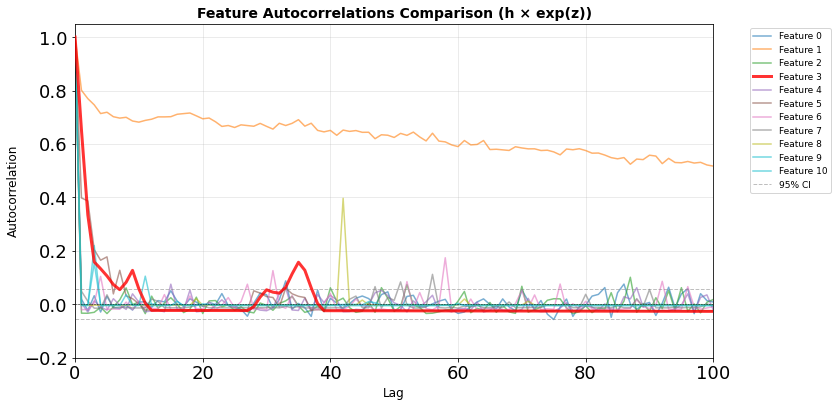


Done!


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def compute_autocorrelation(signal, max_lag=100):
    """
    Compute autocorrelation function for a signal.
    
    Parameters:
    -----------
    signal : array-like, shape (T,)
        Time series signal
    max_lag : int
        Maximum lag to compute
        
    Returns:
    --------
    lags : array, shape (max_lag+1,)
        Lag values from 0 to max_lag
    acf : array, shape (max_lag+1,)
        Autocorrelation values
    """
    signal = np.array(signal)
    signal = signal - np.mean(signal)  # Center the signal
    
    # Normalize by variance at lag 0
    c0 = np.dot(signal, signal) / len(signal)
    
    acf = np.zeros(max_lag + 1)
    acf[0] = 1.0  # Autocorrelation at lag 0 is always 1
    
    for lag in range(1, max_lag + 1):
        if lag < len(signal):
            c_lag = np.dot(signal[:-lag], signal[lag:]) / (len(signal) - lag)
            acf[lag] = c_lag / c0
        else:
            acf[lag] = 0
    
    lags = np.arange(max_lag + 1)
    return lags, acf


def plot_feature_autocorrelations(h, z=None, max_lag=100, feature_subset=None, 
                                   figsize=(15, 10), save_path=None):
    """
    Plot autocorrelations for multiple features.
    
    Parameters:
    -----------
    h : array-like, shape (T, K+1)
        Feature activations over time
    z : array-like, shape (T, K+1), optional
        Continuous modulations. If provided, will plot ACF of h*exp(z)
        If None, will just plot ACF of h
    max_lag : int, default=100
        Maximum lag to compute
    feature_subset : list of int, optional
        Which features to plot. If None, plots all features
    figsize : tuple
        Figure size
    save_path : str, optional
        Path to save the figure
        
    Returns:
    --------
    fig : matplotlib figure
    acf_results : dict
        Dictionary with lags and ACF values for each feature
    """
    h = np.array(h)
    T, K_plus_1 = h.shape
    
    if z is not None:
        z = np.array(z)
        # Compute full signal: h * exp(z)
        signals = h * z
        signal_name = "h × exp(z)"
    else:
        signals = h
        signal_name = "h"
    
    # Determine which features to plot
    if feature_subset is None:
        feature_subset = range(K_plus_1)
    
    n_features = len(feature_subset)
    
    # Compute autocorrelations
    acf_results = {}
    for k in feature_subset:
        lags, acf = compute_autocorrelation(signals[:, k], max_lag)
        acf_results[k] = {'lags': lags, 'acf': acf}
    
    # Create plots
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, k in enumerate(feature_subset):
        ax = axes[idx]
        
        lags = acf_results[k]['lags']
        acf = acf_results[k]['acf']
        
        # Plot autocorrelation
        ax.plot(lags, acf, 'b-', linewidth=2, alpha=0.7)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
        
        # Add confidence interval (95% confidence under white noise assumption)
        conf_interval = 1.96 / np.sqrt(T)
        ax.axhline(y=conf_interval, color='r', linestyle='--', linewidth=1, alpha=0.5)
        ax.axhline(y=-conf_interval, color='r', linestyle='--', linewidth=1, alpha=0.5)
        
        ax.set_xlabel('Lag', fontsize=10)
        ax.set_ylabel('Autocorrelation', fontsize=10)
        ax.set_title(f'Feature {k} ACF ({signal_name})', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.2, 1.05)
        ax.set_xlim(0, max_lag)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig, acf_results


def compare_feature_autocorrelations(h, z=None, max_lag=100, feature_subset=None,
                                      figsize=(12, 6), save_path=None):
    """
    Plot autocorrelations for all features in a single plot for easy comparison.
    
    Parameters:
    -----------
    h : array-like, shape (T, K+1)
        Feature activations over time
    z : array-like, shape (T, K+1), optional
        Continuous modulations
    max_lag : int
        Maximum lag to compute
    feature_subset : list of int, optional
        Which features to plot
    figsize : tuple
        Figure size
    save_path : str, optional
        Path to save the figure
    """
    h = np.array(h)
    T, K_plus_1 = h.shape
    
    if z is not None:
        z = np.array(z)
        signals = h * z
        signal_name = "h × exp(z)"
    else:
        signals = h
        signal_name = "h"
    
    if feature_subset is None:
        feature_subset = range(K_plus_1)
    
    # Compute autocorrelations
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(feature_subset)))
    
    for idx, k in enumerate(feature_subset):
        lags, acf = compute_autocorrelation(signals[:, k], max_lag)
        
        # Make Feature 3 stand out if it's in the subset
        if k == 3:
            ax.plot(lags, acf, color='red', linewidth=3, alpha=0.8, 
                   label=f'Feature {k}', zorder=10)
        else:
            ax.plot(lags, acf, color=colors[idx], linewidth=1.5, alpha=0.6,
                   label=f'Feature {k}')
    
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    # Confidence interval
    conf_interval = 1.96 / np.sqrt(T)
    ax.axhline(y=conf_interval, color='gray', linestyle='--', linewidth=1, 
              alpha=0.5, label='95% CI')
    ax.axhline(y=-conf_interval, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Lag', fontsize=12)
    ax.set_ylabel('Autocorrelation', fontsize=12)
    ax.set_title(f'Feature Autocorrelations Comparison ({signal_name})', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.set_ylim(-0.2, 1.05)
    ax.set_xlim(0, max_lag)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig


def print_acf_summary(h, z=None, max_lag=100, feature_subset=None):
    """
    Print summary statistics about autocorrelations.
    
    Parameters:
    -----------
    h : array-like, shape (T, K+1)
        Feature activations
    z : array-like, shape (T, K+1), optional
        Continuous modulations
    max_lag : int
        Maximum lag to analyze
    feature_subset : list of int, optional
        Which features to analyze
    """
    h = np.array(h)
    T, K_plus_1 = h.shape
    
    if z is not None:
        z = np.array(z)
        signals = h * z
    else:
        signals = h
    
    if feature_subset is None:
        feature_subset = range(K_plus_1)
    
    print("=" * 70)
    print("AUTOCORRELATION SUMMARY")
    print("=" * 70)
    
    for k in feature_subset:
        lags, acf = compute_autocorrelation(signals[:, k], max_lag)
        
        # Find first lag where ACF drops below 0.1
        significant_lags = np.where(acf > 0.1)[0]
        if len(significant_lags) > 1:
            decorrelation_lag = significant_lags[-1]
        else:
            decorrelation_lag = 0
        
        # Average ACF over first 10 lags (excluding lag 0)
        avg_acf_short = np.mean(acf[1:11])
        
        # Check for periodic structure (peaks in ACF)
        # Find local maxima
        peaks = []
        for i in range(2, len(acf)-2):
            if acf[i] > acf[i-1] and acf[i] > acf[i+1] and acf[i] > 0.2:
                peaks.append(i)
        
        print(f"\nFeature {k}:")
        print(f"  ACF at lag 1: {acf[1]:.3f}")
        print(f"  Avg ACF (lags 1-10): {avg_acf_short:.3f}")
        print(f"  Decorrelation lag (ACF < 0.1): {decorrelation_lag}")
        
        if peaks:
            print(f"  Periodic peaks detected at lags: {peaks[:5]}")  # Show first 5
        else:
            print(f"  No strong periodic structure detected")



features_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
print("Computing autocorrelations...")
print_acf_summary(h_h0_learned_reordered, z_z0_learned, max_lag=100, feature_subset=features_to_plot)

print("\nCreating comparison plot...")
compare_feature_autocorrelations(h_h0_learned_reordered, z_z0_learned, max_lag=100,
                                feature_subset=features_to_plot,
                                save_path=None)

print("\nDone!")

In [32]:
theta_learned_reordered = theta_learned[sorted_indices]
theta_h = h_hard_reordered @ theta_learned_reordered
theta_h.shape

(1200, 60)

FEATURE EVALUATION SUMMARY
            sufficient_contribution  has_effect  frequent  spatial_spread  temporal_structure  spatial_coherence  sustained_activation  is_meaningful
feature_0                      True        True      True            True               False               True                  True           True
feature_1                      True        True      True            True               False               True                  True           True
feature_2                     False        True     False           False               False               True                 False          False
feature_3                      True        True     False            True                True               True                 False           True
feature_4                     False        True     False           False               False               True                 False          False
feature_5                      True        True     False            True

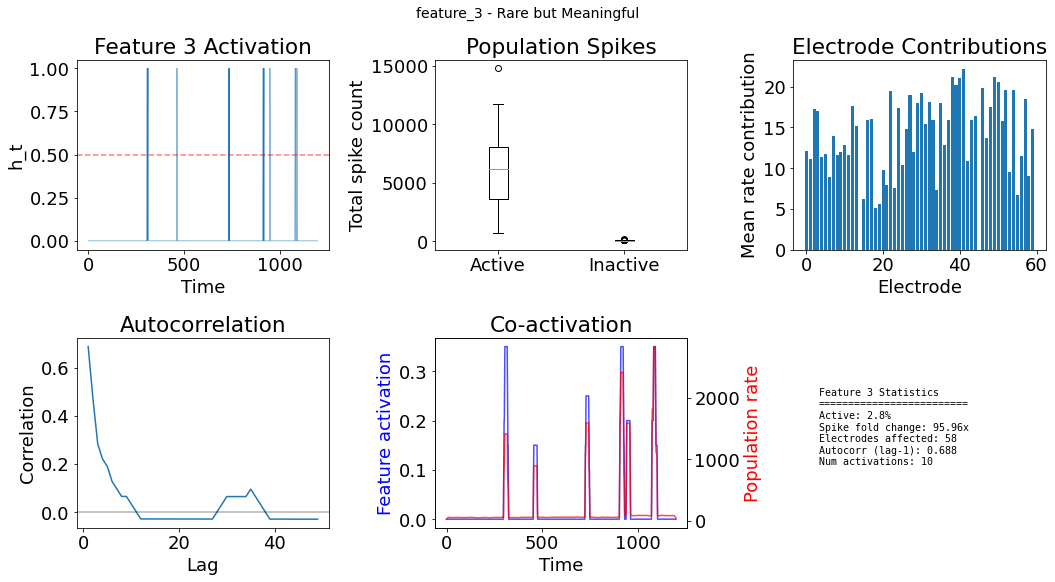


feature_5:
  - Active 2.2% of time
  - 58.8x spike increase when active
  - Affects 49 electrodes
  - Spatial correlation: 1.000
  - Temporal autocorr: 0.484
  * Rare but meaningful (active only 2.2%)


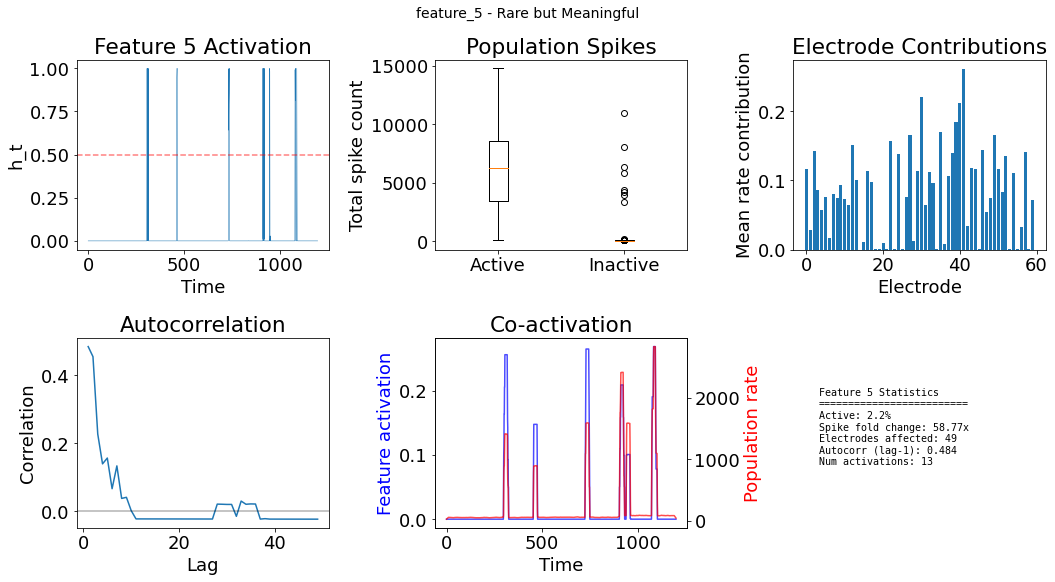

In [34]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import correlate
import matplotlib.pyplot as plt
import seaborn as sns

class FeatureEvaluator:
    def __init__(self, y, h, z, theta, threshold_h=0.5):
        """
        Parameters:
        -----------
        y : array (T, M) - observed spike counts for M electrodes
        h : array (T, K) - feature activations
        z : array (T, K) - latent states
        theta : array (K, M) - feature-electrode weights
        threshold_h : float - threshold for considering h as "active"
        """
        self.y = y
        self.h = h
        self.z = z
        self.theta = theta
        self.threshold_h = threshold_h
        self.T, self.M = y.shape
        self.K = h.shape[1]
        
    def compute_rates(self):
        """Compute the Poisson rates for each feature"""
        # rates[t, k, m] = theta[k, m] * h[t, k] * exp(z[t, k])
        rates = np.zeros((self.T, self.K, self.M))
        for k in range(self.K):
            for m in range(self.M):
                rates[:, k, m] = self.theta[k, m] * self.h[:, k] * self.z[:, k]
        return rates
    
    # ============= 1. EFFECT SIZE WHEN ACTIVE =============
    
    def effect_size_analysis(self):
        """Calculate effect size of each feature when active"""
        results = {}
        rates = self.compute_rates()
        
        for k in range(self.K):
            # Find when feature k is active
            active_mask = self.h[:, k] > self.threshold_h
            inactive_mask = ~active_mask
            
            if active_mask.sum() == 0:
                results[f'feature_{k}'] = {
                    'active_proportion': 0,
                    'mean_rate_when_active': 0,
                    'mean_rate_when_inactive': 0,
                    'rate_fold_change': 0,
                    'spike_fold_change': 0,
                    'electrodes_affected': 0
                }
                continue
            
            # Calculate rates and spikes when active vs inactive
            total_rate_active = rates[active_mask, :, :].sum(axis=1).mean(axis=1)  # sum over features and electrodes
            total_rate_inactive = rates[inactive_mask, :, :].sum(axis=1).mean(axis=1) if inactive_mask.sum() > 0 else 0
            
            # Actual spike counts
            spikes_when_active = self.y[active_mask, :].mean()
            spikes_when_inactive = self.y[inactive_mask, :].mean() if inactive_mask.sum() > 0 else 0
            
            # How many electrodes show significant increase
            electrode_effects = []
            for m in range(self.M):
                rate_contribution = rates[:, k, m]
                if active_mask.sum() > 0:
                    active_contribution = rate_contribution[active_mask].mean()
                    electrode_effects.append(active_contribution)
            
            results[f'feature_{k}'] = {
                'active_proportion': active_mask.mean(),
                'mean_rate_when_active': total_rate_active.mean(),
                'mean_rate_when_inactive': total_rate_inactive.mean() if isinstance(total_rate_inactive, np.ndarray) else total_rate_inactive,
                'rate_fold_change': total_rate_active.mean() / (total_rate_inactive.mean() + 1e-10) if isinstance(total_rate_inactive, np.ndarray) else np.inf,
                'spike_fold_change': spikes_when_active / (spikes_when_inactive + 0.01),
                'electrodes_affected': np.sum(np.array(electrode_effects) > 0.1)  # electrodes with meaningful contribution
            }
            
        return pd.DataFrame(results).T
    
    # ============= 2. SPATIAL COHERENCE =============
    
    def spatial_coherence_analysis(self):
        """Analyze spatial structure of feature effects"""
        results = {}
        rates = self.compute_rates()
        
        for k in range(self.K):
            active_mask = self.h[:, k] > self.threshold_h
            
            if active_mask.sum() < 5:  # Need minimum samples
                results[f'feature_{k}'] = {
                    'mean_pairwise_correlation': np.nan,
                    'participation_ratio': 0,
                    'spatial_entropy': np.nan,
                    'dominant_electrodes': []
                }
                continue
            
            # Get feature k's contribution to each electrode when active
            feature_contribution = rates[active_mask, k, :]  # (n_active, M)
            
            # Pairwise correlation between electrodes
            if feature_contribution.shape[0] > 1:
                corr_matrix = np.corrcoef(feature_contribution.T)
                # Remove diagonal and get mean
                mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
                mean_corr = np.nanmean(corr_matrix[mask])
            else:
                mean_corr = np.nan
            
            # Participation ratio (how many electrodes participate meaningfully)
            mean_contribution = feature_contribution.mean(axis=0)
            participation = (mean_contribution > 0.1 * mean_contribution.max()).sum() / self.M
            
            # Spatial entropy (concentration vs spread)
            if mean_contribution.sum() > 0:
                p = mean_contribution / mean_contribution.sum()
                p = p[p > 0]  # Remove zeros for log
                entropy = -np.sum(p * np.log(p))
                normalized_entropy = entropy / np.log(self.M)  # Normalize by max entropy
            else:
                normalized_entropy = np.nan
            
            # Find dominant electrodes
            dominant_idx = np.argsort(mean_contribution)[-5:][::-1]  # Top 5
            
            results[f'feature_{k}'] = {
                'mean_pairwise_correlation': mean_corr,
                'participation_ratio': participation,
                'spatial_entropy': normalized_entropy,
                'dominant_electrodes': dominant_idx.tolist()
            }
            
        return pd.DataFrame(results).T
    
    # ============= 3. TEMPORAL STRUCTURE =============
    
    def temporal_structure_analysis(self):
        """Analyze temporal patterns of feature activation"""
        results = {}
        
        for k in range(self.K):
            h_k = self.h[:, k]
            active_mask = h_k > self.threshold_h
            
            # Autocorrelation at different lags
            if h_k.std() > 0:
                autocorr_1 = np.corrcoef(h_k[:-1], h_k[1:])[0, 1]
                autocorr_5 = np.corrcoef(h_k[:-5], h_k[5:])[0, 1] if self.T > 5 else np.nan
                autocorr_10 = np.corrcoef(h_k[:-10], h_k[10:])[0, 1] if self.T > 10 else np.nan
            else:
                autocorr_1 = autocorr_5 = autocorr_10 = np.nan
            
            # Find activation events (transitions from inactive to active)
            transitions = np.diff(active_mask.astype(int))
            onset_times = np.where(transitions == 1)[0] + 1
            offset_times = np.where(transitions == -1)[0] + 1
            
            # Inter-activation intervals
            if len(onset_times) > 1:
                iai = np.diff(onset_times)
                mean_iai = iai.mean()
                cv_iai = iai.std() / (iai.mean() + 1e-10)  # Coefficient of variation
            else:
                mean_iai = np.nan
                cv_iai = np.nan
            
            # Duration of active states
            durations = []
            for i, onset in enumerate(onset_times):
                # Find corresponding offset
                offsets_after = offset_times[offset_times > onset]
                if len(offsets_after) > 0:
                    duration = offsets_after[0] - onset
                    durations.append(duration)
            
            if durations:
                mean_duration = np.mean(durations)
                cv_duration = np.std(durations) / (np.mean(durations) + 1e-10)
            else:
                mean_duration = np.nan
                cv_duration = np.nan
            
            # Burstiness measure (Fano factor)
            window_size = 50  # Adjust based on your data
            if self.T > window_size:
                n_windows = self.T // window_size
                counts = []
                for w in range(n_windows):
                    window_active = active_mask[w*window_size:(w+1)*window_size].sum()
                    counts.append(window_active)
                if len(counts) > 1 and np.mean(counts) > 0:
                    fano_factor = np.var(counts) / np.mean(counts)
                else:
                    fano_factor = np.nan
            else:
                fano_factor = np.nan
            
            results[f'feature_{k}'] = {
                'autocorr_lag1': autocorr_1,
                'autocorr_lag5': autocorr_5,
                'autocorr_lag10': autocorr_10,
                'n_activations': len(onset_times),
                'mean_inter_activation_interval': mean_iai,
                'cv_inter_activation': cv_iai,
                'mean_duration': mean_duration,
                'cv_duration': cv_duration,
                'fano_factor': fano_factor
            }
            
        return pd.DataFrame(results).T
    
    # ============= COMBINED CRITERIA =============
    def evaluate_features_improved(self, criteria_thresholds=None):
        """Improved evaluation with better handling of edge cases"""
        
        if criteria_thresholds is None:
            criteria_thresholds = {
                'min_active_proportion': 0.05,
                'min_spike_fold_change': 2.0,  # For excitatory
                'max_spike_fold_change': 0.5,  # For inhibitory (if < 0.5, it's strongly suppressive)
                'min_electrodes_affected': 5,
                'min_autocorr': 0.3,
                'min_spatial_correlation': 0.2,
                'min_absolute_contribution': 0.01,  # Minimum rate contribution to be meaningful
            }
        
        # Get all metrics
        effect_df = self.effect_size_analysis()
        spatial_df = self.spatial_coherence_analysis()
        temporal_df = self.temporal_structure_analysis()
        
        # Calculate mean absolute contribution for each feature
        rates = self.compute_rates()
        mean_contributions = np.array([rates[:, k, :].mean() for k in range(self.K)])
        
        evaluation = pd.DataFrame(index=[f'feature_{k}' for k in range(self.K)])
        
        # Check for sufficient contribution first (avoid near-zero features)
        evaluation['sufficient_contribution'] = mean_contributions > criteria_thresholds['min_absolute_contribution']
        
        # Separate excitatory and inhibitory criteria
        evaluation['excitatory'] = effect_df['spike_fold_change'] > criteria_thresholds['min_spike_fold_change']
        evaluation['inhibitory'] = effect_df['spike_fold_change'] < criteria_thresholds['max_spike_fold_change']
        
        # Original criteria but with guards
        evaluation['frequent'] = effect_df['active_proportion'] > criteria_thresholds['min_active_proportion']
        evaluation['spatial_spread'] = effect_df['electrodes_affected'] > criteria_thresholds['min_electrodes_affected']
        evaluation['temporal_structure'] = temporal_df['autocorr_lag1'].abs() > criteria_thresholds['min_autocorr']
        
        # Fix spatial coherence to handle near-zero cases
        spatial_corr = spatial_df['mean_pairwise_correlation']
        # Set to NaN if contribution is too small
        spatial_corr[~evaluation['sufficient_contribution']] = np.nan
        evaluation['spatial_coherence'] = (spatial_corr > criteria_thresholds['min_spatial_correlation']) & \
                                        evaluation['sufficient_contribution']
        
        # A feature is meaningful if:
        # 1. It has sufficient contribution AND
        # 2. It's either strongly excitatory OR inhibitory AND  
        # 3. Meets at least one other criterion
        evaluation['is_meaningful'] = (
            evaluation['sufficient_contribution'] & 
            (evaluation['excitatory'] | evaluation['inhibitory']) &
            (evaluation['frequent'] | evaluation['spatial_spread'] | 
            evaluation['temporal_structure'] | evaluation['spatial_coherence'])
        )
    
        # Add category labels
        conditions = [
            evaluation['excitatory'] & evaluation['is_meaningful'],
            evaluation['inhibitory'] & evaluation['is_meaningful'],
            ~evaluation['is_meaningful']
        ]
        categories = ['excitatory', 'inhibitory', 'noise']
        evaluation['category'] = np.select(conditions, categories, default='noise')
        
        return evaluation
    
    def evaluate_features(self, criteria_thresholds=None):
        """
        Evaluate features using multiple criteria
        
        Parameters:
        -----------
        criteria_thresholds : dict - Thresholds for each criterion
            Default values provided if None
        """
        if criteria_thresholds is None:
            criteria_thresholds = {
                'min_active_proportion': 0.05,
                'min_spike_fold_change': 2.0,
                'min_electrodes_affected': 5,
                'min_autocorr': 0.3,
                'min_spatial_correlation': 0.2
            }
        
        # Get all metrics
        effect_df = self.effect_size_analysis()
        spatial_df = self.spatial_coherence_analysis()
        temporal_df = self.temporal_structure_analysis()
        
        # Combine into single evaluation
        evaluation = pd.DataFrame(index=[f'feature_{k}' for k in range(self.K)])
        
        # Criterion 1: Appears frequently enough
        evaluation['frequent'] = effect_df['active_proportion'] > criteria_thresholds['min_active_proportion']
        
        # Criterion 2: Strong effect when active
        evaluation['strong_effect'] = effect_df['spike_fold_change'] > criteria_thresholds['min_spike_fold_change']
        
        # Criterion 3: Affects multiple electrodes
        evaluation['spatial_spread'] = effect_df['electrodes_affected'] > criteria_thresholds['min_electrodes_affected']
        
        # Criterion 4: Temporal clustering
        evaluation['temporal_structure'] = temporal_df['autocorr_lag1'] > criteria_thresholds['min_autocorr']
        
        # Criterion 5: Spatial coherence
        evaluation['spatial_coherence'] = spatial_df['mean_pairwise_correlation'] > criteria_thresholds['min_spatial_correlation']
        
        # Overall decision: meaningful if ANY criterion is met
        evaluation['is_meaningful'] = evaluation[['frequent', 'strong_effect', 'spatial_spread', 
                                                  'temporal_structure', 'spatial_coherence']].any(axis=1)
        
        # Add summary statistics
        evaluation['active_proportion'] = effect_df['active_proportion']
        evaluation['spike_fold_change'] = effect_df['spike_fold_change']
        evaluation['n_electrodes'] = effect_df['electrodes_affected']
        
        return evaluation
    
    def evaluate_features_fixed(self, criteria_thresholds=None):
        """
        Fixed evaluation that doesn't require extreme effect sizes
        """
        if criteria_thresholds is None:
            criteria_thresholds = {
                'min_active_proportion': 0.05,
                'min_effect_size': 1.5,  # Any meaningful change (was 2.0)
                'min_absolute_contribution': 0.001,  # Lower threshold (was 0.01)
                'min_electrodes_affected': 5,
                'min_autocorr': 0.3,
                'min_spatial_correlation': 0.2,
            }
        
        # Get metrics
        effect_df = self.effect_size_analysis()
        spatial_df = self.spatial_coherence_analysis()
        temporal_df = self.temporal_structure_analysis()
        
        # Calculate mean absolute contribution
        rates = self.compute_rates()
        mean_contributions = np.array([rates[:, k, :].mean() for k in range(self.K)])
        
        evaluation = pd.DataFrame(index=[f'feature_{k}' for k in range(self.K)])
    
        # More lenient contribution check
        evaluation['sufficient_contribution'] = mean_contributions > criteria_thresholds['min_absolute_contribution']
        
        # Check for ANY meaningful effect (not just extreme)
        evaluation['has_effect'] = (
            (effect_df['spike_fold_change'] > criteria_thresholds['min_effect_size']) |  # Increases spikes
            (effect_df['spike_fold_change'] < 1/criteria_thresholds['min_effect_size'])  # Decreases spikes
        )
        
        # Supporting criteria
        evaluation['frequent'] = effect_df['active_proportion'] > criteria_thresholds['min_active_proportion']
        evaluation['spatial_spread'] = effect_df['electrodes_affected'] > criteria_thresholds['min_electrodes_affected']
        evaluation['temporal_structure'] = temporal_df['autocorr_lag1'].abs() > criteria_thresholds['min_autocorr']
        evaluation['spatial_coherence'] = spatial_df['mean_pairwise_correlation'] > criteria_thresholds['min_spatial_correlation']
        
        # NEW: Also check for clear visual structure in h
        # If a feature is clearly "on" for sustained periods, it's likely meaningful
        evaluation['sustained_activation'] = False
        for k in range(self.K):
            h_k = self.h[:, k]
            if h_k.max() > 0:
                # Check if feature stays on for meaningful durations
                active_mask = h_k > self.threshold_h
                if active_mask.any():
                    # Find run lengths
                    runs = []
                    current_run = 0
                    for val in active_mask:
                        if val:
                            current_run += 1
                        else:
                            if current_run > 0:
                                runs.append(current_run)
                            current_run = 0
                    if current_run > 0:
                        runs.append(current_run)
                    
                    # If any activation lasts >10 time points, it's sustained
                    if runs and max(runs) > 10:
                        evaluation.loc[f'feature_{k}', 'sustained_activation'] = True
        
        # RELAXED CRITERIA: 
        # Meaningful if has sufficient contribution OR sustained activation
        # AND meets at least one other criterion
        evaluation['is_meaningful'] = (
            (evaluation['sufficient_contribution'] | evaluation['sustained_activation']) &
            (evaluation['frequent'] | evaluation['spatial_spread'] | 
            evaluation['temporal_structure'] | evaluation['spatial_coherence'] |
            evaluation['has_effect'])
        )
        
        return evaluation
    
    # ============= VISUALIZATION =============
    
    def plot_feature_summary(self, feature_k):
        """Create a comprehensive plot for a single feature"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        
        # 1. Activation pattern over time
        ax = axes[0, 0]
        ax.plot(self.h[:, feature_k], linewidth=0.5)
        ax.axhline(self.threshold_h, color='r', linestyle='--', alpha=0.5)
        ax.set_title(f'Feature {feature_k} Activation')
        ax.set_xlabel('Time')
        ax.set_ylabel('h_t')
        
        # 2. Effect on spike rates
        ax = axes[0, 1]
        active_mask = self.h[:, feature_k] > self.threshold_h
        if active_mask.sum() > 0:
            spikes_active = self.y[active_mask, :].sum(axis=1)
            spikes_inactive = self.y[~active_mask, :].sum(axis=1) if (~active_mask).sum() > 0 else []
            
            data_to_plot = []
            labels = []
            if len(spikes_active) > 0:
                data_to_plot.append(spikes_active)
                labels.append('Active')
            if len(spikes_inactive) > 0:
                data_to_plot.append(spikes_inactive)
                labels.append('Inactive')
            
            if data_to_plot:
                bp = ax.boxplot(data_to_plot, labels=labels)
                ax.set_title('Population Spikes')
                ax.set_ylabel('Total spike count')
        
        # 3. Spatial pattern
        ax = axes[0, 2]
        rates = self.compute_rates()
        mean_contribution = rates[:, feature_k, :].mean(axis=0)
        ax.bar(range(self.M), mean_contribution)
        ax.set_title('Electrode Contributions')
        ax.set_xlabel('Electrode')
        ax.set_ylabel('Mean rate contribution')
        
        # 4. Autocorrelation
        ax = axes[1, 0]
        if self.h[:, feature_k].std() > 0:
            lags = range(1, min(50, self.T//2))
            autocorr = [np.corrcoef(self.h[:-lag, feature_k], self.h[lag:, feature_k])[0, 1] 
                       for lag in lags]
            ax.plot(lags, autocorr)
            ax.axhline(0, color='k', linestyle='-', alpha=0.3)
            ax.set_title('Autocorrelation')
            ax.set_xlabel('Lag')
            ax.set_ylabel('Correlation')
        
        # 5. Co-activation with spikes
        ax = axes[1, 1]
        window = 20
        h_smooth = np.convolve(self.h[:, feature_k], np.ones(window)/window, mode='same')
        y_smooth = np.convolve(self.y.sum(axis=1), np.ones(window)/window, mode='same')
        
        ax2 = ax.twinx()
        ax.plot(h_smooth, 'b-', alpha=0.7, label='Feature activation')
        ax2.plot(y_smooth, 'r-', alpha=0.7, label='Population spikes')
        ax.set_xlabel('Time')
        ax.set_ylabel('Feature activation', color='b')
        ax2.set_ylabel('Population rate', color='r')
        ax.set_title('Co-activation')
        
        # 6. Summary statistics
        ax = axes[1, 2]
        ax.axis('off')
        
        effect_df = self.effect_size_analysis()
        temporal_df = self.temporal_structure_analysis()
        
        stats_text = f"Feature {feature_k} Statistics\n"
        stats_text += f"{'='*25}\n"
        stats_text += f"Active: {effect_df.loc[f'feature_{feature_k}', 'active_proportion']:.1%}\n"
        stats_text += f"Spike fold change: {effect_df.loc[f'feature_{feature_k}', 'spike_fold_change']:.2f}x\n"
        stats_text += f"Electrodes affected: {int(effect_df.loc[f'feature_{feature_k}', 'electrodes_affected'])}\n"
        stats_text += f"Autocorr (lag-1): {temporal_df.loc[f'feature_{feature_k}', 'autocorr_lag1']:.3f}\n"
        stats_text += f"Num activations: {int(temporal_df.loc[f'feature_{feature_k}', 'n_activations'])}\n"
        
        ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='center', fontfamily='monospace')
        
        plt.tight_layout()
        return fig

# ============= USAGE EXAMPLE =============

def analyze_features(y, h, z, theta):
    """
    Main analysis function
    
    Parameters:
    -----------
    y : array (T, M) - spike counts
    h : array (T, K) - feature activations  
    z : array (T, K) - latent states
    theta : array (K, M) - weights
    """
    evaluator = FeatureEvaluator(y, h, z, theta)
    
    # Get comprehensive evaluation
    evaluation = evaluator.evaluate_features_fixed()
    
    print("="*60)
    print("FEATURE EVALUATION SUMMARY")
    print("="*60)
    print(evaluation.to_string())
    
    # Identify meaningful features
    meaningful = evaluation[evaluation['is_meaningful']]
    noise = evaluation[~evaluation['is_meaningful']]
    
    print(f"\nMeaningful features: {meaningful.index.tolist()}")
    print(f"Noise features: {noise.index.tolist()}")
    
    # Detailed analysis for meaningful features
    print("\n" + "="*60)
    print("DETAILED ANALYSIS OF MEANINGFUL FEATURES")
    print("="*60)
    
    effect_df = evaluator.effect_size_analysis()
    spatial_df = evaluator.spatial_coherence_analysis()
    temporal_df = evaluator.temporal_structure_analysis()
    
    for feat in meaningful.index:
        print(f"\n{feat}:")
        print(f"  - Active {effect_df.loc[feat, 'active_proportion']:.1%} of time")
        print(f"  - {effect_df.loc[feat, 'spike_fold_change']:.1f}x spike increase when active")
        print(f"  - Affects {int(effect_df.loc[feat, 'electrodes_affected'])} electrodes")
        print(f"  - Spatial correlation: {spatial_df.loc[feat, 'mean_pairwise_correlation']:.3f}")
        print(f"  - Temporal autocorr: {temporal_df.loc[feat, 'autocorr_lag1']:.3f}")
        
        # Get feature number for plotting
        k = int(feat.split('_')[1])
        
        # Create detailed plot for sparse but meaningful features
        if effect_df.loc[feat, 'active_proportion'] < 0.05:
            print(f"  * Rare but meaningful (active only {effect_df.loc[feat, 'active_proportion']:.1%})")
            fig = evaluator.plot_feature_summary(k)
            plt.suptitle(f'{feat} - Rare but Meaningful', fontsize=14, y=1.02)
            plt.show()
    
    return evaluation, evaluator

# Example call:
evaluation, evaluator = analyze_features(data.T, h_h0_learned_reordered, z_z0_learned, theta_theta0_learned_reordered)

In [35]:
from matplotlib.colors import LogNorm
def plot_all_circular_matrices(matrices, num_rows, num_cols,subtitle=False, cmap='cool', s=500):
    """
    Plots all matrices as subplots with circular markers, ignoring NaN values.
    
    Parameters:
    - matrices (3D numpy array): Array of shape (K, nrows, ncols), where K is the number of matrices (subnetworks).
    - cmap (str): Colormap to use for coloring the values.
    - s (int): Size of the markers.
    """
    K, nrows, ncols = matrices.shape  # Get the number of matrices, rows, and columns

    # Calculate number of rows and columns for the subplot grid
    ncols_subplot = num_cols
    nrows_subplot = num_rows
    global_vmin = np.nanmin(matrices)
    global_vmax = np.nanmax(matrices)
    # Create a figure with subplots
    fig, axes = plt.subplots(nrows_subplot, ncols_subplot, figsize=(4 * ncols_subplot, 4 * nrows_subplot))

    # Flatten the axes array to make it easier to loop through
    axes = axes.flatten()

    # Loop through each matrix and plot it
    for k in range(K):
        ax = axes[k]  # Get the k-th axis
        data = matrices[k]  # Extract the k-th matrix

        # Create a grid of positions for the markers
        x, y = np.meshgrid(np.arange(ncols), np.arange(nrows))

        # Flatten the data matrix for scatter plot
        x_flat = x.flatten()
        y_flat = y.flatten()
        data_flat = data.flatten()

        # Filter out NaN values
        valid_mask = ~np.isnan(data_flat)  # Mask for valid (non-NaN) values

        # Create a scatter plot with only valid data points
        sc = ax.scatter(x_flat[valid_mask], y_flat[valid_mask], s=s, c=data_flat[valid_mask], cmap=cmap, 
                        marker='o', edgecolor=None, vmin=global_vmin, vmax=global_vmax)

        # Set the limits, so the scatter points align correctly
        ax.set_xlim(-0.5, ncols - 0.5)
        ax.set_ylim(-0.5, nrows - 0.5)

        # Invert y-axis to align with matrix orientation
        ax.invert_yaxis()

        # Remove ticks and labels if needed
        ax.set_xticks([])
        ax.set_yticks([])

        # Remove spines (the black borders around the plot)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Set aspect ratio to be equal to make square plots
        ax.set_aspect('equal', adjustable='box')

        # Add title to each subplot
        ax.set_title(f"$\\theta_{{{k}}}$", fontsize=20)
        if subtitle:
            ax.set_title(f"DIV {k*7+14}", fontsize=16)
    # If the number of subplots is greater than the number of matrices, hide the extra axes
    for k in range(K, len(axes)):
        fig.delaxes(axes[k])

    # Create a colorbar outside of the subplots grid
    fig.subplots_adjust(bottom=0.25)  # Adjust bottom to make space for the colorbar
    # cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height] for colorbar
    cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.03])
    cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=15)
    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0, 0.1, 1, 1], pad=0.2)  # Leave space for the colorbar
    
    

In [36]:
def plot_all_circular_matrices(matrices, num_rows, num_cols,subtitle=False, cmap='cool', s=500):
    """
    Plots all matrices as subplots with circular markers, ignoring NaN values.
    
    Parameters:
    - matrices (3D numpy array): Array of shape (K, nrows, ncols), where K is the number of matrices (subnetworks).
    - cmap (str): Colormap to use for coloring the values.
    - s (int): Size of the markers.
    """
    K, nrows, ncols = matrices.shape  # Get the number of matrices, rows, and columns

    # Calculate number of rows and columns for the subplot grid
    ncols_subplot = num_cols
    nrows_subplot = num_rows
    global_vmin = np.nanmin(matrices)
    global_vmax = np.nanmax(matrices)
    # Create a figure with subplots
    fig, axes = plt.subplots(nrows_subplot, ncols_subplot, figsize=(4 * ncols_subplot, 4 * nrows_subplot))

    # Flatten the axes array to make it easier to loop through
    axes = axes.flatten()

    # Loop through each matrix and plot it
    for k in range(K):
        ax = axes[k]  # Get the k-th axis
        data = matrices[k]  # Extract the k-th matrix

        # Create a grid of positions for the markers
        x, y = np.meshgrid(np.arange(ncols), np.arange(nrows))

        # Flatten the data matrix for scatter plot
        x_flat = x.flatten()
        y_flat = y.flatten()
        data_flat = data.flatten()

        # Filter out NaN values
        valid_mask = ~np.isnan(data_flat)  # Mask for valid (non-NaN) values

        # Create a scatter plot with only valid data points
        sc = ax.scatter(x_flat[valid_mask], y_flat[valid_mask], s=s, c=data_flat[valid_mask], cmap=cmap, 
                        marker='o', edgecolor=None, vmin=global_vmin, vmax=global_vmax)

        # Set the limits, so the scatter points align correctly
        ax.set_xlim(-0.5, ncols - 0.5)
        ax.set_ylim(-0.5, nrows - 0.5)

        # Invert y-axis to align with matrix orientation
        ax.invert_yaxis()

        # Remove ticks and labels if needed
        ax.set_xticks([])
        ax.set_yticks([])

        # Remove spines (the black borders around the plot)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Set aspect ratio to be equal to make square plots
        ax.set_aspect('equal', adjustable='box')

        # Add title to each subplot
        ax.set_title(f"$\\theta_{{{k}}}$", fontsize=20)
        if subtitle:
            ax.set_title(f"DIV {k*7+14}", fontsize=16)
    # If the number of subplots is greater than the number of matrices, hide the extra axes
    for k in range(K, len(axes)):
        fig.delaxes(axes[k])

    # Create a colorbar outside of the subplots grid
    fig.subplots_adjust(bottom=0.25)  # Adjust bottom to make space for the colorbar
    # cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height] for colorbar
    cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.03])
    cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=15)
    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0, 0.1, 1, 1], pad=0.2)  # Leave space for the colorbar
    
  

/tmp/ipykernel_2654558/3032898180.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1], pad=0.2)  # Leave space for the colorbar


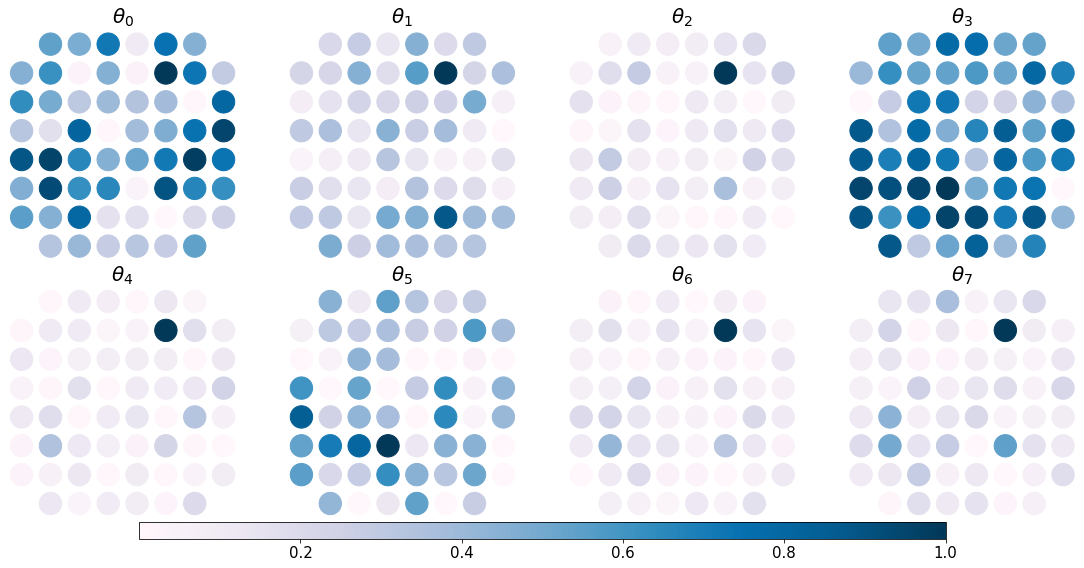

In [38]:
theta_theta0_learned_reordered = np.vstack((np.abs(model.theta0.detach().cpu().numpy()), theta_learned_reordered))
thetas_scaled = theta_theta0_learned_reordered / theta_theta0_learned_reordered.max(axis=1)[:, None]  ## changed from max to sum


theta_mat_reshaped = reshape_rows_with_corners_as_nans(thetas_scaled)
# theta_mat_reshaped = thetas_scaled.reshape((K+1), 8, 8)
# theta_mat_reshaped_log = np.log(theta_mat_reshaped)
# theta_mat_reshaped_log_scaled = theta_mat_reshaped_log/theta_mat_reshaped_log.max(axis=1)[:, None]  ## CHECK THIS!!! SCALE THE COLORBAR!

plot_all_circular_matrices(theta_mat_reshaped[np.insert(np.mean(h_learned_reordered, axis=0)>0.01, 0, 6)], 2, 4, cmap="PuBu")
# plt.savefig("hp_plots/toupdate/tc043_tc165_div14_theta.png")
# plt.savefig("hp_plots/toupdate/tc165_div14_subgraph.png")
# plt.savefig("hp_plots/tc043_tc165_div14_subgraph.png")
# plt.savefig("hp_plots/tc043_div14_dup_subgraph.png")
# plt.savefig("hp_plots/toupdate/tc043_div14_subgraph.pdf")
# plt.savefig("developmental_plots/p5a2_subgraph.png")
# plt.savefig("hp_plots/toupdate/tc043dup_subgraph.pdf")

In [37]:
K = 5

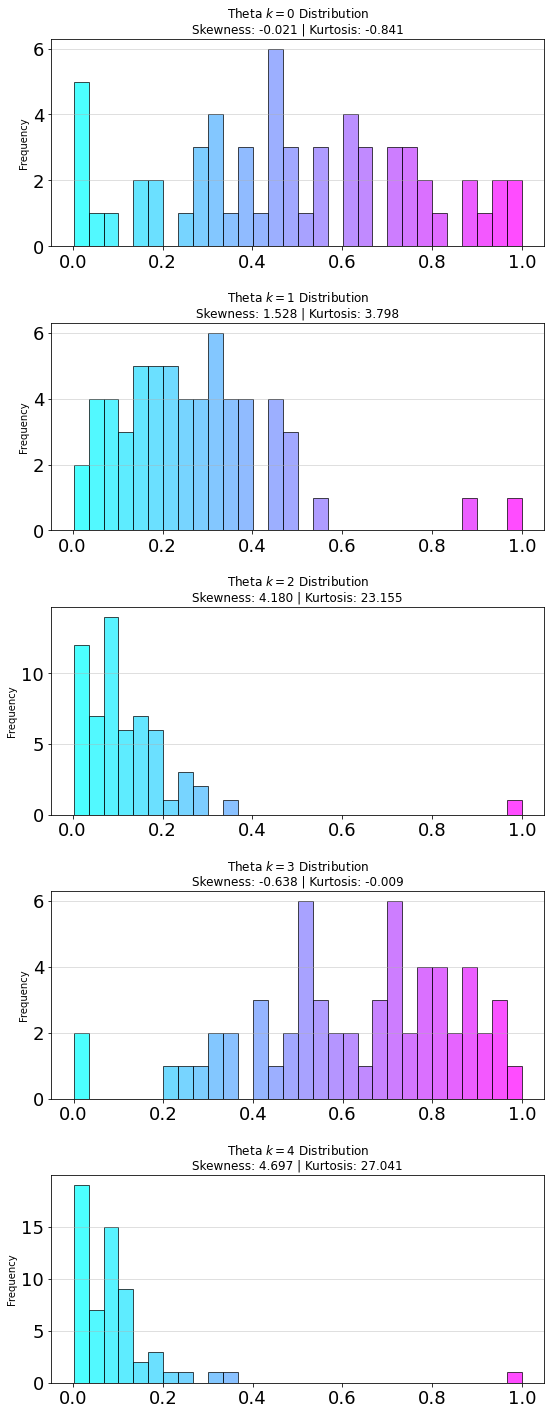

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis
from matplotlib import cm # Import for colormaps

fig, axes = plt.subplots(K, 1, figsize=(8, 4 * K))

# Define the colormap you want to use
colormap = cm.get_cmap('cool')

# 3. Loop through each row (k element) and plot the histogram
for k in range(K):
    data = thetas_scaled[k, :]
    
    # --- 1. Plot with 'cool' color scheme ---
    n, bins, patches = axes[k].hist(
        data, 
        bins=30, 
        edgecolor='black', 
        alpha=0.7
    )
    
    # Normalize the bin values to range from 0 to 1 for the colormap
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    col = bin_centers - min(bin_centers)
    col /= max(col)
    
    # Apply the 'cool' colormap to the bars
    for c, p in zip(col, patches):
        plt.setp(p, 'facecolor', colormap(c))
        
    # --- 2. Calculate and Report Kurtosis and Skewness ---
    data_skewness = skew(data)
    data_kurtosis = kurtosis(data) # By default, returns Fisher's kurtosis (excess kurtosis)
    
    # Create the title with the reported statistics
    title_text = (
        f'Theta $k={k}$ Distribution\n'
        f'Skewness: {data_skewness:.3f} | Kurtosis: {data_kurtosis:.3f}'
    )
    
    axes[k].set_title(title_text, fontsize=12)
    axes[k].set_ylabel('Frequency', fontsize=10)
    axes[k].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [33]:
z0_learned = output["z0"].detach().cpu().numpy()

In [321]:
z_scaled = (np.exp(z_learned_reordered) * theta_theta0_learned_reordered.max(axis=1)[1:(K+1)])
z0_scaled = (np.exp(z0_learned) * theta_theta0_learned_reordered.max(axis=1)[0])
learned_zh = z_scaled * h_learned_reordered
z_h_learned_noise = np.hstack([z0_scaled, learned_zh])

In [322]:
# theta_h_z = (h_hard_reordered*np.exp(z_learned_reordered)) @ theta_learned_reordered
# theta_h_z_total = theta_h_z + output["mu0_approx"].detach().cpu().numpy()
# theta_h_z_total_reshape = theta_h_z_total.reshape(2, int(data.shape[0]/2), -1)
# theta_h_z_mean = theta_h_z_total_reshape.mean(axis=1)
# # plot_all_circular_matrices((theta_h_z_mean).reshape(4, 8, 8), 1, 4, subtitle=T, cmap="PuRd")
# plot_all_circular_matrices(reshape_rows_with_corners_as_nans(theta_h_z_mean), 1, 2, subtitle=T, cmap="PuRd")

# # plt.savefig("developmental_plots/p5a2_theta_h_z_mean.png")

In [323]:
def count_switches(data, threshold=0.5):
    """
    data: shape (K, T) -- each row is a time-series of nearly-binary values.
    threshold: float -- values >= threshold will be treated as 1, else 0.

    Returns: an array of length K giving the number of 0↔1 switches for each row.
    """
    T, K = data.shape
    switch_counts = np.zeros((K, 2), dtype=int)
    
    for k in range(K):
        # Convert row to binary based on threshold
        binary_row = (data[:, k] >= threshold).astype(int)
        # Compare adjacent entries to see where they differ
        diffs = binary_row[1:] != binary_row[:-1]
        # Sum of True values in 'diffs' is the total number of switches
        switch_counts[k, 0] = np.sum(diffs[:int(T/2)])
        switch_counts[k, 1] = np.sum(diffs[int(T/2):T])
    
    return switch_counts


In [324]:
switch_counts_by_h = count_switches(h_hard_reordered)

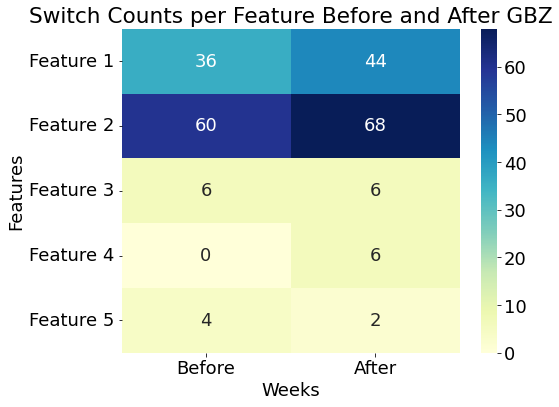

In [325]:
K = switch_counts_by_h.shape[0]

plt.figure(figsize=(8, 6))
sns.heatmap(switch_counts_by_h,
            annot=True, fmt='d', cmap="YlGnBu",
            xticklabels=["Before", "After"],
            yticklabels=[f"Feature {i+1}" for i in range(K)])
plt.title("Switch Counts per Feature Before and After GBZ")
plt.xlabel("Weeks")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


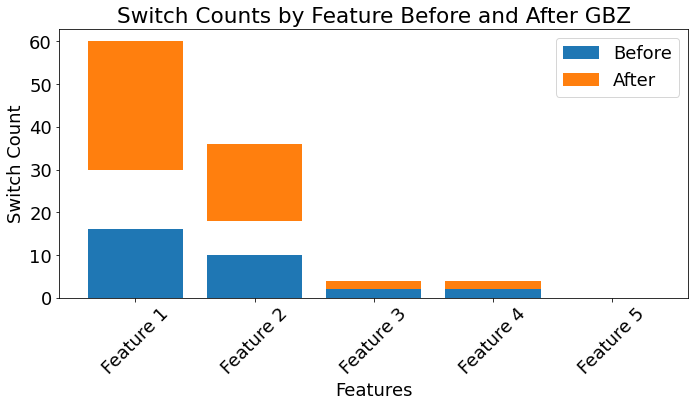

In [80]:
K = switch_counts_by_h.shape[0]
features = np.arange(K)

# Extract the switch counts for each week across features
before = switch_counts_by_h[:, 0]
after = switch_counts_by_h[:, 1]

plt.figure(figsize=(10, 6))
plt.bar(features, before, label="Before")
plt.bar(features, after, bottom=after, label="After")

plt.xticks(features, [f"Feature {i+1}" for i in features])
plt.xticks(rotation=45)
plt.title("Switch Counts by Feature Before and After GBZ")
plt.xlabel("Features")
plt.ylabel("Switch Count")
plt.legend()
plt.tight_layout()
plt.show()


In [419]:
# for i in range(K+1):
#     plot_circular_matrix(theta_theta0_learned_reordered[i].reshape(8, 8), title="Subnetwork "+str(i))
#     savepath = "figures/developmental_fig/p1b2_subgraph"+str(i)+".png"
#     # plt.savefig(savepath)

In [420]:
# import numpy as np
# import igraph as ig
# import matplotlib.pyplot as plt

# # Define the threshold value
# threshold = 0.5

# def create_adjacency_matrix(row, threshold):
#     """Creates an adjacency matrix for a given row based on the threshold."""
#     adj_matrix = np.zeros((D, D))  # Initialize adjacency matrix for D nodes
#     selected_nodes = np.where(row > threshold)[0]  # Find indices where value exceeds threshold
    
#     # Create connections between selected nodes
#     for i in selected_nodes:
#         for j in selected_nodes:
#             if i != j:
#                 adj_matrix[i, j] = 1  # Connection between node i and j
#     return adj_matrix

# def plot_chord_diagram(ax, adj_matrix, row_index):
#     """Plots the chord diagram based on the adjacency matrix using igraph."""
#     g = ig.Graph.Adjacency((adj_matrix > 0).tolist(), mode=ig.ADJ_UNDIRECTED)  # Create undirected graph
#     g.vs["label"] = [f"{i+1}" for i in range(D)]  # Label nodes as 'Node 1', 'Node 2', etc.
#     layout = g.layout("circle")  # Set circular layout

#     # Plot the graph
#     ig.plot(g, layout=layout, vertex_size=10, vertex_color="skyblue", vertex_label=None,
#             vertex_frame_width=2, vertex_frame_color="black", 
#             edge_color="gray", edge_width=0.8, edge_curved=True, target=ax)
    
#     # Manually add labels outside the circle
#     angles = np.linspace(0, 2 * np.pi, D, endpoint=False)
#     for i, label in enumerate(g.vs["label"]):
#         angle = angles[i]
#         x, y = layout[i]
#         alignment = ('left' if np.sin(angle) >= 0 else 'right')
#         ax.text(x * 1.2, y * 1.2, label, size=10, ha=alignment, va="center",
#                 rotation=np.degrees(angle), rotation_mode="anchor")
    
#     ax.set_title(f'Row {row_index+1}', fontsize=12)
#     ax.set_aspect('equal')  # Ensure circular (not elliptical) plots
#     ax.set_facecolor('white')  # Set axis background color to white

# # Set up the subplot grid (5 plots per row and 2 rows)
# num_cols = 5
# num_rows = 2

# fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 8))  # Adjusted figure size

# # Set figure background to white
# fig.patch.set_facecolor('white')

# # Generate K adjacency matrices and corresponding chord plots in subplots
# for i in range(K):
#     row = matrix[i, :]  # Get the i-th row
#     adj_matrix = create_adjacency_matrix(row, threshold)  # Create adjacency matrix
    
#     # Plot in the corresponding subplot
#     ax = axs[i // num_cols, i % num_cols]  # Select the correct subplot
#     plot_chord_diagram(ax, adj_matrix, i)

# # Hide any unused subplots (if K < num_rows * num_cols)
# for j in range(K, num_rows * num_cols):
#     fig.delaxes(axs[j // num_cols, j % num_cols])

# plt.tight_layout()
# plt.show()


In [39]:
# h_fromzh_hard = (z_h_learned_noise > 2)[:, 1:]

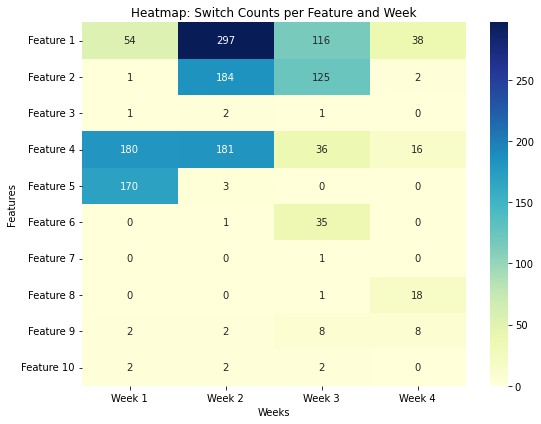

In [430]:
# K = switch_counts_by_h_fromzh.shape[0]

# plt.figure(figsize=(8, 6))
# sns.heatmap(switch_counts_by_h_fromzh,
#             annot=True, fmt='d', cmap="YlGnBu",
#             xticklabels=[f"Week {i+1}" for i in range(4)],
#             yticklabels=[f"Feature {i+1}" for i in range(K)])
# plt.title("Heatmap: Switch Counts per Feature and Week")
# plt.xlabel("Weeks")
# plt.ylabel("Features")
# plt.tight_layout()
# plt.show()


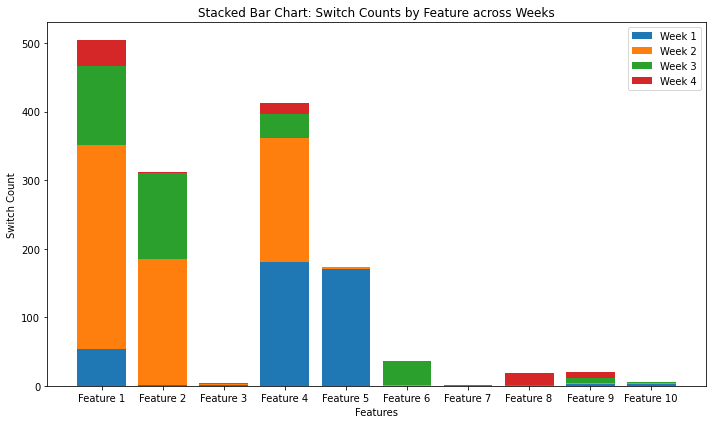

In [431]:
# features = np.arange(K)

# # Extract the switch counts for each week across features
# week1 = switch_counts_by_h_fromzh[:, 0]
# week2 = switch_counts_by_h_fromzh[:, 1]
# week3 = switch_counts_by_h_fromzh[:, 2]
# week4 = switch_counts_by_h_fromzh[:, 3]

# plt.figure(figsize=(10, 6))
# plt.bar(features, week1, label="Week 1")
# plt.bar(features, week2, bottom=week1, label="Week 2")
# plt.bar(features, week3, bottom=week1+week2, label="Week 3")
# plt.bar(features, week4, bottom=week1+week2+week3, label="Week 4")

# plt.xticks(features, [f"Feature {i+1}" for i in features])
# plt.title("Stacked Bar Chart: Switch Counts by Feature across Weeks")
# plt.xlabel("Features")
# plt.ylabel("Switch Count")
# plt.legend()
# plt.tight_layout()
# plt.show()


/home/yg8229/dynamic_net/network_visualization.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1], pad=0.2)  # Leave space for the colorbar


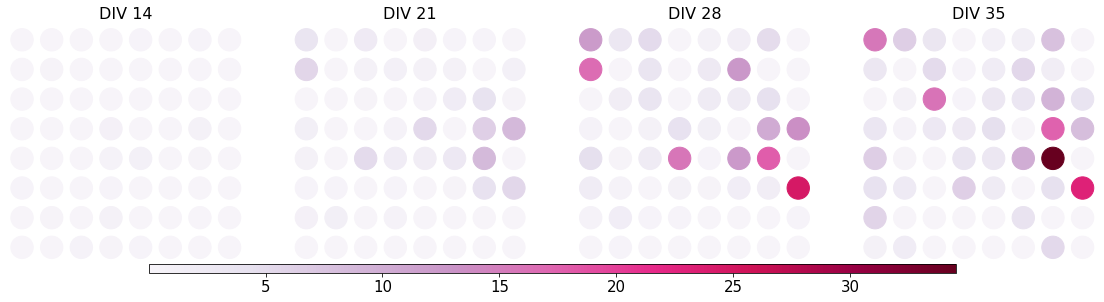

In [48]:
# theta_h_z = (h_hard_reordered*np.exp(z_learned_reordered)) @ theta_learned_reordered
# theta_h_z_total = theta_h_z + output["mu0_approx"].detach().cpu().numpy()
# theta_h_z_total_reshape = theta_h_z_total.reshape(4, 600, -1)
# theta_h_z_mean = theta_h_z_total_reshape.mean(axis=1)
# plot_all_circular_matrices((theta_h_z_mean).reshape(4, 8, 8), 1, 4, subtitle=T, cmap="PuRd")

In [47]:
# theta_h_z_mean.shape

(4, 64)

In [29]:
# hz = (h_hard_reordered*np.exp(z_learned_reordered))

In [30]:
# hz_reshape = hz.reshape(4, 600, K)

In [31]:
# hz_weekly = np.mean(hz_reshape, axis=1)

In [ ]:
# theta_mat_reshaped = reshape_rows_with_corners_as_nans(thetas_scaled)
# thetas_scaled.shape


In [33]:
# theta_reshaped = reshape_rows_with_corners_as_nans(theta_learned_reordered)

In [ ]:
# theta_reshaped.shape

In [ ]:
# theta_learned_reordered[0].shape

In [ ]:
# thetas_scaled.shape

In [ ]:
# theta_k = reshape_rows_with_corners_as_nans(theta_learned_reordered[0].reshape(1, 60)).reshape(8, 8)
# theta_k.shape

In [ ]:
# hz_weekly.shape

In [39]:
# fig, axs = plt.subplots(1, K, figsize=(20, 5))
# for k in range(K):

#     hz_k = hz_weekly[:, k]
#     M_k = hz_weekly[:, k, np.newaxis, np.newaxis] * theta_reshaped[k]

#     plot_all_circular_matrices(M_k, num_cols=4, num_rows=1, cmap='cool')


In [ ]:
# M_K = hz_weekly[:, :, np.newaxis, np.newaxis] * theta_reshaped[np.newaxis, :, :, :]
# M_K.shape

In [41]:
# weekly_sub_path = "figures/newdata_weeklysub/"+"_".join(str.split(data_path, "/")[-1].split(".")[0].split("_")[0:3])+".pdf"

# plot_circular_matrices_4xK_colorbars_on_right(M_K, cmap='PuRd', s=200, subtitle=False, save_path=weekly_sub_path)

In [206]:
# gif_path = "figures/newdata_fig/"+"_".join(str.split(data_path, "/")[-1].split(".")[0].split("_")[0:3])+".gif"

In [207]:
# animate_bubble_matrices_vertical(
#     M_K, 
#     cmap="PuRd", 
#     s=200, 
#     save_path=gif_path
# )

In [ ]:
# plot_all_circular_matrices(reshape_rows_with_corners_as_nans(theta_h_z_mean), 1, 4, subtitle=T, cmap="PuRd")

In [213]:
# import numpy as np
# from scipy.stats import wasserstein_distance

# def wasserstein_distance_samples(A, B):
#     """
#     Compute the 1D Wasserstein distance between arrays A and B,
#     interpreting them as sets of samples.
#     NaNs are removed, not treated as zeros.
#     """
#     # Remove NaNs (ignore them)
#     A_clean = A[~np.isnan(A)]
#     B_clean = B[~np.isnan(B)]
    
#     # If either is empty after removing NaNs, return 0 or handle as appropriate
#     if len(A_clean) == 0 or len(B_clean) == 0:
#         return 0.0
    
#     # SciPy computes the 1D Wasserstein distance directly
#     dist = wasserstein_distance(A_clean, B_clean)
#     return dist

In [214]:
# dist_scipy = wasserstein_distance_samples(theta_h_z_mean[0], theta_h_z_mean[1])

In [ ]:
# import numpy as np
# import itertools
# from scipy.stats import wasserstein_distance, entropy

# def total_variation_distance(x, y, normalize=True):
#     """
#     Compute the total variation distance between two 1D arrays x and y.
#     If 'normalize' is True, we interpret the arrays as distributions:
#       1) We ensure non-negativity by clipping below at 0.
#       2) We normalize so each sums to 1 (if possible).
#     Then TV(p, q) = 0.5 * sum(|p(i) - q(i)|).
#     """
#     if len(x) != len(y):
#         raise ValueError("Arrays must be the same length.")

#     # Copy to avoid modifying originals
#     a = x.copy()
#     b = y.copy()

#     # If we interpret them as probability distributions:
#     # 1) Clip negatives to 0
#     # 2) Normalize so they sum to 1
#     if normalize:
#         a = np.clip(a, 0, None)
#         b = np.clip(b, 0, None)
#         sum_a = np.sum(a)
#         sum_b = np.sum(b)
#         if sum_a > 0:
#             a = a / sum_a
#         if sum_b > 0:
#             b = b / sum_b

#     # Compute TV distance
#     return 0.5 * np.sum(np.abs(a - b))


# def wasserstein_distance_samples(x, y):
#     """
#     Compute the 1D Wasserstein distance (Earth Mover's Distance)
#     between two arrays x and y, treating each as a set of samples.
#     """
#     # Directly use scipy's function
#     return wasserstein_distance(x, y)

# def abs_distance(x, y):
#     return np.abs(x - y)
# # --------------------------------------------------------


#     # Create matrices to hold pairwise distances

# N = 4
# tv_matrix = np.zeros((N, N))
# w_matrix = np.zeros((N, N))
# abs_matrix = np.zeros((N, N, D))
# kl_matrix = np.zeros((N, N))
# labels = ["DIV14", "DIV21", "DIV28", "DIV35"]

# df_results = pd.DataFrame(columns=["WeekA", "WeekB", "TV", "Wasserstein", "KL_pq", "KL_qp"])
# # Iterate over all unique pairs (i, j)
# for i, j in itertools.combinations(range(N), 2):
#     arr_i = theta_h_z_mean[i]
#     arr_j = theta_h_z_mean[j]

#     # Total Variation distance
#     tv_d = total_variation_distance(arr_i, arr_j, normalize=True)
#     # Wasserstein distance
#     w_d = wasserstein_distance_samples(arr_i, arr_j)
#     kl_pq = entropy(pk = arr_i/np.sum(arr_i), qk = arr_j/np.sum(arr_j))
#     kl_qp = entropy(pk = arr_j/np.sum(arr_j), qk = arr_i/np.sum(arr_i))

#     # Fill symmetric matrices
#     tv_matrix[i, j] = tv_d
#     tv_matrix[j, i] = tv_d
#     w_matrix[i, j] = w_d
#     w_matrix[j, i] = w_d
#     abs_matrix[i, j] = abs_distance(arr_i, arr_j)
#     abs_matrix[j, i] = abs_distance(arr_j, arr_i)
#     kl_matrix[i, j] = kl_pq
#     kl_matrix[j, i] = kl_qp
#     df_results.loc[len(df_results)]={"WeekA": labels[i], "WeekB": labels[j], "TV": tv_d, "Wasserstein": w_d, "KL_pq": kl_pq, "KL_qp": kl_qp}

# # Print the final distance matrices
# print("\nTotal Variation Distance Matrix:\n", tv_matrix)
# print("\nWasserstein Distance Matrix:\n", w_matrix)
# print("\nKL Divergence Matrix:\n", kl_matrix)
# dist_savepath = "results/newdata/dist_results/"+"_".join(str.split(data_path, "/")[-1].split(".")[0].split("_")[0:3])+"_distances.csv"

# df_results.to_csv(dist_savepath, index=False)

In [ ]:
# dist_savepath = "results/newdata/dist_results/"+"_".join(str.split(data_path, "/")[-1].split(".")[0].split("_")[0:3])+"_distances.csv"
# dist_savepath

In [217]:
# abs_mat_reshaped = np.asarray([reshape_rows_with_corners_as_nans(abs_matrix[i]) for i in range(4)])

In [ ]:
# plot_circular_matrices_4xK_colorbars_on_right(abs_mat_reshaped, "Blues", dist=T)

In [ ]:
# fig = plt.figure(figsize=(6, 6))
# plt.imshow(tv_matrix, cmap="Oranges")
# plt.xticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.yticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.title("Pairwise Distance: Total Variation")
# # plt.savefig("p3b1_h_similarity.png")
# plt.show()

In [ ]:
# fig = plt.figure(figsize=(6, 6))
# plt.imshow(w_matrix, cmap="Purples")
# plt.xticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.yticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.title("Pairwise Distance: Wasserstein")
# # plt.savefig("p3b1_h_similarity.png")
# plt.show()

In [ ]:
# fig = plt.figure(figsize=(6, 6))
# plt.imshow(kl_matrix, cmap="Greens")
# plt.xticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.yticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.title("Pairwise Distance: KL divergence")
# # plt.savefig("p3b1_h_similarity.png")
# plt.show()

<!-- #### mu approx plot -->

In [ ]:
# mu_approx_plot = mu_approx + output["mu0_approx"].detach().numpy()
# mu_approx_plot.shape

In [408]:
# tmp = td.poisson.Poisson(torch.from_numpy(mu_approx) + output["mu0_approx"]).log_prob(torch.from_numpy(data))

In [409]:
# mu_pred = output["mu_approx"] + output["mu0_approx"]

In [ ]:
# fig = plt.figure(figsize=(15, 6))
# plt.imshow(np.minimum(mu_approx_plot.T, np.quantile(mu_approx_plot, .95)), aspect="auto", interpolation="none", cmap="plasma")
# plt.axvline(x=600, color='lavender', linestyle=':')
# plt.axvline(x=1200, color='lavender', linestyle=':')
# plt.axvline(x=1800, color='lavender', linestyle=':')
# plt.show()

In [ ]:
# # Creating the plots with adjusted ticks
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

# # Original data plot
# img1 = ax[0].imshow(mu_approx_plot.T, aspect="auto", cmap="plasma", interpolation="none")
# ax[0].set_title('Approximated Rate P1B2', fontsize=14)
# ax[0].set_xlabel('Time', fontsize=12)
# ax[0].set_ylabel('Electrodes', fontsize=12)
# ax[0].grid(False)
# ax[1].invert_yaxis()

# # Set ticks with reduced frequency for x-ticks (e.g., every 200th tick) and y-ticks (e.g., every 5th tick)
# xticks = np.arange(0, data.shape[0], step=200)
# yticks = np.arange(0, data.shape[1], step=5)
# ax[0].set_xticks(xticks)
# ax[0].set_yticks(yticks)
# ax[0].set_xticklabels(xticks)
# ax[0].set_yticklabels(yticks + 1)

# # Set y-limits explicitly to avoid layout issues
# ax[0].set_ylim(0, data.shape[1])

# # Adding vertical lines and ensuring they stay within plot limits
# # ax[0].vlines([600, 1200, 1800], ymin=0, ymax=data.shape[1], color='lavender', linestyle=':')
# ax[0].vlines([600], ymin=0, ymax=data.shape[1], color='skyblue')

# # Add color bar to the original plot
# cbar1 = fig.colorbar(img1, ax=ax[0])
# cbar1.set_label('Amplitude')

# # Capped data plot
# img2 = ax[1].imshow(np.minimum(mu_approx_plot, 8).T, aspect="auto", cmap="plasma", interpolation="none")
# ax[1].set_title('Approximated Rate P1B2 (Capped at 8 for visualization)', fontsize=14)
# ax[1].set_xlabel('Time', fontsize=12)
# ax[1].set_ylabel('Electrodes', fontsize=12)
# ax[1].grid(False)

# # Adding vertical lines to the capped plot
# # ax[1].vlines([600, 1200, 1800], ymin=0, ymax=data.shape[1], color='lavender', linestyle=':')
# ax[1].vlines([600], ymin=0, ymax=data.shape[1], color='skyblue')

# # Set y-limits for the capped data plot as well
# ax[1].set_ylim(0, data.shape[1])

# # Set ticks with reduced frequency for x-ticks (e.g., every 200th tick) and y-ticks (e.g., every 5th tick)
# ax[1].set_xticks(xticks)
# ax[1].set_yticks(yticks)
# ax[1].set_xticklabels(xticks)
# ax[1].set_yticklabels(yticks + 1)

# # Add color bar to the capped data plot
# cbar2 = fig.colorbar(img2, ax=ax[1])
# cbar2.set_label('Capped Amplitude (max 8)')

# # Adjust spacing between subplots and avoid excess white space at the bottom
# fig.subplots_adjust(left=0.1, right=0.9, top=0.8, bottom=0.1, hspace=0.1, wspace=0.3)
# # plt.savefig("p3b1_mu_approx.png")
# plt.show()


<!-- #### Weekly correlation -->

In [412]:
# h1 = h_learned_reordered[0:600]
# h2 = h_learned_reordered[600:1200]
# h3 = h_learned_reordered[1200:1800]
# h4 = h_learned_reordered[1800:]

In [ ]:
# h_mean = np.array([h1.mean(axis=0), h2.mean(axis=0), h3.mean(axis=0), h4.mean(axis=0)])
# h_mean.shape

In [ ]:
# h_mean @ h_mean.T

In [ ]:
# fig = plt.figure(figsize=(6, 6))
# plt.imshow((h_mean @ h_mean.T)/K, cmap="binary")
# plt.xticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.yticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.title("Pairwise Similarity of H across Weeks")
# plt.savefig("p3b1_h_similarity.png")
# plt.show()

In [ ]:
# fig = plt.figure(figsize=(6, 6))
# plt.imshow(cosine_similarity(h_mean), cmap="binary")
# plt.xticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.yticks(np.arange(4), ["DIV14", "DIV21", "DIV28", "DIV35"])
# plt.title("Pairwise Cosine Similarity of H across Weeks")
# plt.savefig("p3b1_h_cosine_similarity.png")
# plt.show()

<!-- ### Light stimulation -->

In [118]:
# output_path = output_path_prefix+files[1]+"_K"+str("6")+"_set"+str("3")+ "_seed"+str("9")+".pth"
# model_path = output_path.replace("output", "model")

<!-- #### Data visualization -->

In [ ]:
# # Creating the plots with adjusted ticks
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

# # Original data plot
# img1 = ax[0].imshow(data.T, aspect="auto", cmap="plasma", interpolation="none")
# ax[0].set_title('Original Data', fontsize=14)
# ax[0].set_xlabel('Time', fontsize=12)
# ax[0].set_ylabel('Electrodes', fontsize=12)
# ax[0].grid(False)

# # Set ticks with reduced frequency for x-ticks (e.g., every 200th tick) and y-ticks (e.g., every 5th tick)
# xticks = np.arange(0, data.shape[0], step=100)
# yticks = np.arange(0, data.shape[1], step=5)
# ax[0].set_xticks(xticks)
# ax[0].set_yticks(yticks)
# ax[0].set_xticklabels(xticks + 1)
# ax[0].set_yticklabels(yticks + 1)

# # Set y-limits explicitly to avoid layout issues
# ax[0].set_ylim(0, data.shape[1])

# # Adding vertical lines and ensuring they stay within plot limits
# ax[0].vlines([600], ymin=0, ymax=data.shape[1], color='deepskyblue', linestyle='--')

# # Add color bar to the original plot
# cbar1 = fig.colorbar(img1, ax=ax[0])
# cbar1.set_label('Amplitude')

# # Capped data plot
# img2 = ax[1].imshow(np.minimum(data, 8).T, aspect="auto", cmap="plasma", interpolation="none")
# ax[1].set_title('Data (Capped at 8 for visualization)', fontsize=14)
# ax[1].set_xlabel('Time', fontsize=12)
# ax[1].set_ylabel('Electrodes', fontsize=12)
# ax[1].grid(False)

# # Adding vertical lines to the capped plot
# ax[1].vlines([600], ymin=0, ymax=data.shape[1], color='deepskyblue', linestyle='--')

# # Set y-limits for the capped data plot as well
# ax[1].set_ylim(0, data.shape[1])

# # Set ticks with reduced frequency for x-ticks (e.g., every 200th tick) and y-ticks (e.g., every 5th tick)
# ax[1].set_xticks(xticks)
# ax[1].set_yticks(yticks)
# ax[1].set_xticklabels(xticks + 1)
# ax[1].set_yticklabels(yticks + 1)

# # Add color bar to the capped data plot
# cbar2 = fig.colorbar(img2, ax=ax[1])
# cbar2.set_label('Capped Amplitude (max 8)')

# # Adjust spacing between subplots and avoid excess white space at the bottom
# fig.subplots_adjust(left=0.1, right=0.9, top=0.7, bottom=0.1, hspace=0.1, wspace=0.3)

# plt.show()


In [123]:
# K = 6

In [ ]:
# output = torch.load(output_path)
# T, D = output["mu_approx"].shape
# model = AEVB(T=T, D=D, K=K)
# model.load_state_dict(torch.load(model_path))

In [125]:
# h_learned = torch.sigmoid(output['h_logit']).detach().cpu().numpy()
# z_learned = output['z'].detach().cpu().numpy()
# theta_learned = torch.abs(model.theta).detach().cpu().numpy()
# mu_approx = output['mu_approx'].detach().cpu().numpy()

In [126]:
# h_hard = (h_learned>0.5)
# count_ones = np.sum(h_hard, axis=0)

# # Step 3: Sort the indices based on the count of ones in descending order
# sorted_indices = np.argsort(-count_ones)

# # Step 4: Reorder the arrays using the sorted indices
# h_hard_sorted = h_hard[:, sorted_indices]
# h_est_sorted = h_learned[:, sorted_indices]

In [127]:
# h_learned_reordered = h_learned[:, sorted_indices]
# h_hard_reordered = h_hard[:, sorted_indices]   
# z_learned_reordered = z_learned[:, sorted_indices]

In [ ]:
# fig = plt.figure(figsize=(15, 6))
# plt.imshow(h_learned_reordered.T, aspect="auto", interpolation="none")
# plt.axvline(x=600, color = 'deepskyblue', label = 'axvline - full height')
# plt.xlabel("time (s)")
# plt.ylabel("Process")
# plt.colorbar()
# plt.show()

In [ ]:
# # m = nn.Softplus()
# # theta_learned = m(model.theta).detach().numpy()
# theta_learned = torch.abs(model.theta).detach().cpu().numpy()
# theta_learned_reordered = theta_learned[sorted_indices]
# fig = plt.figure(figsize=(12, 5))
# plt.imshow(np.minimum(theta_learned_reordered, 3), aspect="auto")

# plt.colorbar()
# plt.show()

In [ ]:
# fig = plt.figure(figsize=(15, 6))
# plt.plot(np.exp(z_learned_reordered))
# plt.axvline(x=600, color = 'deepskyblue', label = 'axvline - full height')
# plt.xlabel("time")
# plt.ylabel("Amplitude")
# plt.show()

In [ ]:
# fig = plt.figure(figsize=(15, 6))
# learned_zh = np.exp(z_learned_reordered) * h_learned_reordered
# # plt.plot(learned_zh, alpha=0.5)
# plt.imshow(np.minimum(learned_zh.T, 4), aspect="auto", interpolation="none", cmap="plasma")
# plt.colorbar()

# plt.show()

In [ ]:
# theta_h = h_learned_reordered @ theta_learned_reordered
# theta_h.shape

In [ ]:
# fig = plt.figure(figsize=(15, 6))
# plt.imshow(theta_h.T, aspect="auto", interpolation="none", cmap="plasma")
# plt.axvline(x=600, color = 'deepskyblue', label = 'axvline - full height')
# plt.colorbar()
# plt.show()

In [158]:
# Create a new array of size 64 by K with zeros (or NaNs)
# new_array = np.zeros((64, K))
# Alternatively, use NaNs:
new_array = np.full((64, K), np.nan)

# Indices to skip (the corners of the 8x8 matrix)
skip_indices = [0, 7, 56, 63]

# Insert original values into new_array, skipping the corners
for k in range(K):
  insert_index = 0
  for i in range(64):
      if i not in skip_indices:
          new_array[i, k] = theta_learned_reordered.T[insert_index, k]
          insert_index += 1

# Reshape the array into K matrices of size 8x8
reshaped_array = new_array.T.reshape(K, 8, 8)



In [ ]:
# data_path1 = "hp_files/tc048_DIV21.npy"
# data_path2 = "hp_files/tc164_DIV21.npy"
# data1 = np.load(data_path1)
# data2 = np.load(data_path2)
# data_dup = np.concatenate([data1, data2], axis=0)
# data_dup.shape
# np.save("hp_dup/tc048_tc164_DIV21.npy", data_dup)

<!-- ### Number of changes -->

In [191]:
# import numpy as np

# def count_changes_in_window_for_each_column(binary_matrix, window_size=10):
#     # Get the number of rows and columns
#     T, N = binary_matrix.shape
    
#     # Initialize a list to store the change counts for each window
#     change_counts_per_column = []
    
#     # Loop over the matrix with the specified window size
#     for i in range(0, T, window_size):
#         window = binary_matrix[i:i+window_size, :]  # Extract the window
#         if window.shape[0] < 2:  # If the window is too small to compare, skip
#             continue
        
#         # Compute the changes between consecutive elements along each column
#         changes_per_column = np.sum(np.abs(np.diff(window, axis=0)), axis=0)
#         change_counts_per_column.append(changes_per_column)
    
#     # Convert the list into a numpy array (rows: windows, columns: N)
#     change_counts_per_column = np.array(change_counts_per_column)
    
#     return change_counts_per_column

# # Example usage:
# changes_per_column = count_changes_in_window_for_each_column(h_hard_reordered, window_size=10)
# print(changes_per_column.shape)

(120, 10)


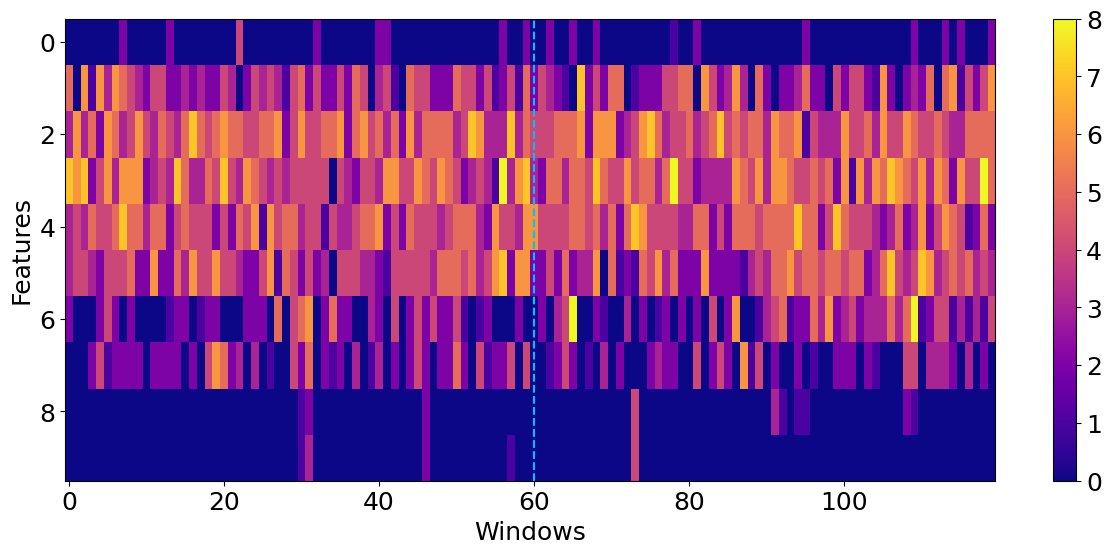

In [192]:
# fig = plt.figure(figsize=(15, 6))
# plt.imshow(changes_per_column.T, aspect="auto", cmap="plasma", interpolation="none")
# plt.axvline(60, color='deepskyblue', linestyle='--')
# plt.xlabel("Windows")
# plt.ylabel("Features")
# plt.colorbar()
# plt.show()

In [ ]:
# def count_switches(data, threshold=0.5):
#     """
#     data: shape (K, T) -- each row is a time-series of nearly-binary values.
#     threshold: float -- values >= threshold will be treated as 1, else 0.

#     Returns: an array of length K giving the number of 0↔1 switches for each row.
#     """
#     K, T = data.shape
#     switch_counts = np.zeros((K, 4), dtype=int)
    
#     for k in range(K):
#         # Convert row to binary based on threshold
#         binary_row = (data[k] >= threshold).astype(int)
#         # Compare adjacent entries to see where they differ
#         diffs = binary_row[1:] != binary_row[:-1]
#         # Sum of True values in 'diffs' is the total number of switches
#         switch_counts[k, 0] = np.sum(diffs[:600])
#         switch_counts[k, 1] = np.sum(diffs[600:1200])
#         switch_counts[k, 2] = np.sum(diffs[1200:1800])
#         switch_counts[k, 3] = np.sum(diffs[1800:])
    
#     return switch_counts


In [ ]:
# K = switch_counts_by_h.shape[0]
# features = np.arange(K)

# # Extract the switch counts for each week across features
# week1 = switch_counts_by_h[:, 0]
# week2 = switch_counts_by_h[:, 1]
# week3 = switch_counts_by_h[:, 2]
# week4 = switch_counts_by_h[:, 3]

# plt.figure(figsize=(10, 6))
# plt.bar(features, week1, label="Week 1")
# plt.bar(features, week2, bottom=week1, label="Week 2")
# plt.bar(features, week3, bottom=week1+week2, label="Week 3")
# plt.bar(features, week4, bottom=week1+week2+week3, label="Week 4")

# plt.xticks(features, [f"Feature {i+1}" for i in features])
# plt.title("Stacked Bar Chart: Switch Counts by Feature across Weeks")
# plt.xlabel("Features")
# plt.ylabel("Switch Count")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [ ]:
# def plot(output, model, gt, file_str,T,D,K, vmax_percentile = 95):
#     plt.rcParams.update({'font.size': 18})
#     vmax = np.percentile(gt, vmax_percentile)
#     h_learned = torch.sigmoid(output['h_logit']).detach().cpu().numpy()
#     z_learned = output['z'].detach().cpu().numpy()
    
#     mu_approx = output['mu_approx'].detach().cpu().numpy()
#     z0_learned = output['z0'].detach().cpu().numpy()
#     mu0_approx = output['mu0_approx'].detach().cpu().numpy()
#     h_hard = (h_learned>0.5)
#     count_ones = np.sum(h_hard, axis=0)

#     sorted_indices = np.argsort(-count_ones)
#     h_learned_reordered = h_learned[:, sorted_indices]
#     z_learned_reordered = z_learned[:, sorted_indices]
#     theta_learned = torch.abs(model.theta).detach().cpu().numpy()
#     theta_learned_reordered = theta_learned[sorted_indices]
#     theta_scale =theta_learned_reordered.max(axis=1)
#     #theta_scale /=2
#     z_learned_scaled = np.exp(z_learned_reordered) * theta_scale
    
#     z_h_learned = z_learned_scaled * h_learned_reordered
#     z_z0_learned = np.hstack([z0_learned, z_h_learned])
    
#     fig = plt.figure(figsize=(.5*K,T/100))
#     ax = plt.axes()
#     im = ax.imshow(h_learned_reordered, aspect='auto', interpolation="none", cmap='Greys')
#     #ax.set_title("True h")
#     ax.set_ylabel("Time")
#     ax.set_xlabel("Feature")
#     ax.set_xticks(range(K), np.arange(1, K+1))
#     ax.set_yticks(np.arange(0, T, 100))
#     # plt.savefig("figures/true_h.png")
#     cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
#     plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
#     plt.savefig("figures/{}_learned_h.png".format(file_str),bbox_inches='tight')
#     plt.show()
    
#     fig = plt.figure(figsize=(.5*(K+1),T/100))
#     ax = plt.axes()
#     im = ax.imshow(z_z0_learned, aspect='auto', interpolation='None', cmap="plasma", vmin=0, vmax=vmax)
#     #ax.set_title("Learned Theta")
#     ax.set_ylabel("Time")
#     ax.set_xlabel("Feature")
#     ax.set_xticks(range(K+1))
#     ax.set_yticks(np.arange(0, T, 100))
#     cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
#     plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
#     plt.savefig("figures/{}learned_zh.png".format(file_str),bbox_inches='tight')
#     plt.show()
    
    
    
#     fig = plt.figure(figsize=(5,T/100))
#     ax = plt.axes()
#     im = ax.imshow(gt, aspect='auto', interpolation='None', cmap="plasma", vmin=0, vmax=vmax)
#     #ax.set_title("Learned Theta")
#     ax.set_ylabel("Time")
#     ax.set_xlabel("Electrode")
#     ax.set_xticks(np.arange(9, D, 10), np.arange(10, D+1, 10))
#     ax.set_yticks(np.arange(0, T, 100))
#     cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
#     plt.colorbar(im, cax=cax) # Similar to fig.colorbar(im, cax = cax)
#     # plt.savefig("figures/{}raster.png".format(file_str),bbox_inches='tight')
#     plt.show()
    

In [ ]:
# import numpy as np
# import igraph as ig
# import matplotlib.pyplot as plt

# # Create an igraph Graph from the binary adjacency matrix and make it undirected
# g = ig.Graph.Adjacency((adj_matrix > 0).tolist(), mode=ig.ADJ_UNDIRECTED)

# # Add node labels
# n = adj_matrix.shape[0]
# g.vs["label"] = [f"{i+1}" for i in range(n)]  # Label nodes as '1', '2', etc.

# # Set the layout to circular
# layout = g.layout("circle")

# # Compute label rotation angles
# angles = np.linspace(0, 2 * np.pi, n, endpoint=False)  # Angles for each node in the circle

# # Plot the graph
# fig, ax = plt.subplots(figsize=(8, 8))

# # Customize the label distance and alignment
# visual_style = {
#     "layout": layout,
#     "vertex_size": 10,            # Adjust node size
#     "vertex_color": "skyblue",    # Node color
#     "vertex_frame_width": 2,      # Thicker node border
#     "vertex_frame_color": "black",# Border color
#     "edge_color": "gray",         # Edge color
#     "edge_width": 0.8,            # Edge thickness
#     "edge_curved": True,          # Curved edges
#     "vertex_label": None,         # Remove numbers from nodes
#     "bbox": (600, 600),           # Size of the plot
#     "margin": 50                  # Margin around the plot
# }

# ig.plot(g, **visual_style, target=ax)

# # Manually add node labels with rotation
# for i, label in enumerate(g.vs["label"]):
#     angle = angles[i]
#     x, y = layout[i]
#     # Rotate labels according to their position
#     alignment = ('left' if np.sin(angle) >= 0 else 'right')
#     ax.text(x * 1.1, y * 1.1, label, size=10, ha=alignment, va="center",
#             rotation=np.degrees(angle), rotation_mode="anchor")

# plt.show()
